# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `ArtBench-10/artbench-10-python/artbench-10-batches-py/`
- `ArtBench-10/ArtBench-10.csv`

If you do not have it on the folder, download from kaggle directly:

https://www.kaggle.com/datasets/alexanderliao/artbench10


In [2]:
from __future__ import annotations

%pip install -q "torch-fidelity>=0.3,<1.0"
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

In [3]:
import os
import shutil
from google.colab import drive

# Forcefully clean the directory if it's causing mount conflicts
if os.path.exists('/content/drive'):
    print("Remove local path to remount...")
    try:
        #shutil.rmtree('/content/drive')
        # Usiamo il comando di sistema per smontare correttamente
        !fusermount -u /content/drive
        print("Clean completed.")
    except Exception as e:
        print(f"Error while cleaning: {e}. Try to rename.")
        os.rename('/content/drive', '/content/drive_backup')

# # Attempt to delete the directory tree
print("Try mounting...")
drive.mount('/content/drive', force_remount=True)

# If the folder is locked, rename it as a fallback strategy
if os.path.exists('/content/drive/MyDrive'):
    print("Drive mount correctly!")
    !mkdir -p /content/artbench_local
    !unzip -o -q "/content/drive/MyDrive/GenerativeAI/GenAI_Project/TP1-alunos-src-only/ArtBench-10.zip" -d "/content/artbench_local"
    print("Dataset unzip locally!")
else:
    print("Mount doesn't work or MyDrive does not exist")

Mounted at /content/drive
Drive mount correctly!
Dataset unzip locally!


In [4]:
# Check for available hardware acceleration to optimize training performance
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Device:', device)

Device: cuda


In [5]:
# --- REPRODUCIBILITY SETUP ---
# Set a global seed to ensure that stochastic operations (shuffling, initialization) 
# produce the same results across different runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- DIRECTORY & PATH CONFIGURATION ---
# Define the root path for the project within Google Drive.
PROJECT_ROOT = Path('/content/drive/MyDrive/GenerativeAI/GenAI_Project/TP1-alunos-src-only').resolve()
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'

if not KAGGLE_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Run this notebook from student_start_pack/ or adjust PROJECT_ROOT.'
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT  =', KAGGLE_ROOT)

PROJECT_ROOT = /content/drive/.shortcut-targets-by-id/1D5marWek97vM4aPSOqX6PyweONel1WI9/GenerativeAI/GenAI_Project/TP1-alunos-src-only
KAGGLE_ROOT  = /content/drive/.shortcut-targets-by-id/1D5marWek97vM4aPSOqX6PyweONel1WI9/GenerativeAI/GenAI_Project/TP1-alunos-src-only/ArtBench-10


In [6]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
# Map images folders into manage objects, and CSV files into HuggingFace Datasets
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]
test_hf = hf_ds["test"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

print("Test size:", len(test_hf))
print("Columns   :", test_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='/content/drive/.shortcut-targets-by-id/1D5marWek97vM4aPSOqX6PyweONel1WI9/GenerativeAI/GenAI_Project/TP1-alunos-src-only/ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Test size: 10000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [7]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


**Note** : The dataset is perfectly balanced across all classes. Since each category contains exactly 5,000 samples, there is no risk of class bias, and no further data balancing techniques (such as oversampling or class weighting) are required.

## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [8]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])


"""
Take original dataset and wrap it into a PyTorch Dataset, applying the transform on the fly.
"""
class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


"""
Make a subset of indices for a dataset.
"""
def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    # Compute the number of samples to keep based on the fraction
    n_keep = max(1, int(round(n_total * fraction)))
    # For reproducibility, use a seeded random generator to shuffle indices
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

# Wrap the HuggingFace dataset into a PyTorch Dataset, applying the transform on the fly.
train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [9]:
import csv

"""
Load training IDs from a CSV file.
"""

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('/content/drive/MyDrive/GenerativeAI/GenAI_Project/TP1-alunos-src-only/student_start_pack/training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


### Build dataloaders for both AE/VAE and GAN

In [10]:
def build_artbench_loaders(
    train_hf,
    test_hf,
    batch_size=BATCH_SIZE,
    use_gan_norm=False,
    train_ids=None,
    image_size=IMAGE_SIZE
):
    """
    Constructs PyTorch DataLoaders for ArtBench-10 with configurable normalization.
    
    Args:
        train_hf, test_hf: HuggingFace dataset splits.
        batch_size: Number of samples per gradient update.
        use_gan_norm: Boolean to switch between [0, 1] and [-1, 1] normalization.
        train_ids: Optional list of indices (e.g., for the 20% subset or 50k full set).
        image_size: Target resolution (32x32).
    """
    
    # Manage the AE/VAE and the GAN normalization differences with a simple transform switch
    if use_gan_norm:
        transform = T.Compose([
        T.Resize(image_size, interpolation=T.InterpolationMode.BILINEAR),
        T.CenterCrop(image_size),
        T.ToTensor(),  # # Converts PIL image to [0, 1] tensor
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [0,1] -> [-1,1]   
        ])
        print("Preprocessing: using GAN/Diffusion normalization ([-1,1])")
    else:
        transform = T.Compose([
            T.Resize(image_size, interpolation=T.InterpolationMode.BILINEAR),
            T.CenterCrop(image_size),
            T.ToTensor(),  # outputs [0,1]
        ])
        print("Preprocessing: using AE/VAE normalization ([0,1])")
    
    # Initialize custom Dataset wrappers
    # If train_ids is None, the wrapper will default to the full dataset (50,000 images).
    train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_ids)
    test_ds = HFDatasetTorch(test_hf, transform=transform)

    effective_workers = safe_num_workers(NUM_WORKERS)

    # Training DataLoader: Shuffled to ensure stochastic gradient descent
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=effective_workers,
        pin_memory=torch.cuda.is_available(),
    )

    # Testing DataLoader: Sequential for consistent evaluation metrics
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=effective_workers,
    )

    return train_loader, test_loader

## Visualize a sample grid

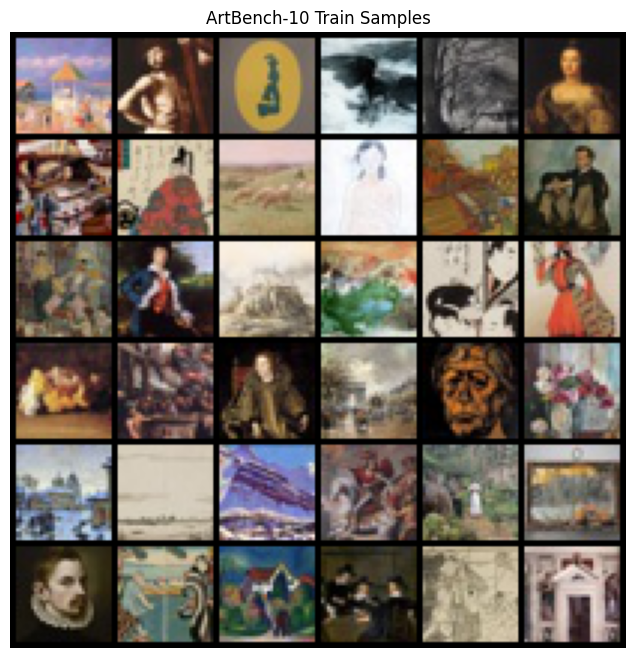

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [11]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [12]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data/train_subset/images
Metadata CSV: exported_data/train_subset/metadata.csv


#### Helper Functions

In [13]:
import json
from pathlib import Path
import torch

# --- DIRECTORY SETUP ---
# Define paths for saving model weights (.pth) and training history (.json)
MODEL_DIR = Path('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models')
HISTORY_DIR = Path('/content/drive/MyDrive/GenerativeAI/GenAI_Project/History')

# Create directories if they do not exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

# Toggle this to False if you want to force retraining
USED_SAVED_IF_EXISTS = True

def slugify_name(str) -> str:

    """
    Converts a model name into a filesystem-friendly string (slug).
    Example: "My Best VAE!" -> "my_best_vae"
    """

    stem = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str)
    stem = '_'.join(part for part in stem.split('_') if part)
    return stem or 'model'

def path_for_model(model_name: str) -> Path:

    """Generates standardized file paths for model weights and history files."""

    stem = slugify_name(model_name)
    return MODEL_DIR / f"{stem}.pth", HISTORY_DIR / f"{stem}_history.json"

def fit_or_load_model(model, name, train_function, load_if_available=USED_SAVED_IF_EXISTS, **train_kwargs):

    """
    Core function to manage the training lifecycle:
    1. Checks if a pre-trained version of the model exists.
    2. Loads weights and history if available to save time.
    3. Otherwise, triggers the training function and saves the results.
    """
    
    model_path, history_path = path_for_model(name)

    # Check for existing files to avoid redundant training
    if load_if_available and model_path.exists() and history_path.exists():
        print(f"Upload model \"{name}\" from: {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=device))
        with open(history_path, 'r', encoding='utf-8') as f:
            history = json.load(f)
        return history
    

    # --- TRAINING (if file doesn't exists or if we want to retrain) ---
    print(f'Model "{name}" not found or retraining. Start training...')
    history = train_function(model=model, **train_kwargs)

    # Save weights
    with model_path.open('wb') as f:
        torch.save(model.state_dict(), f)
    
    # Save history
    with history_path.open('w', encoding='utf-8') as f:
        json.dump(history, f, indent=2)
    torch.save(model.state_dict(), model_path)
    with open(history_path, 'w', encoding='utf-8') as f:
        json.dump(history, f, indent=2)

    print(f'Model saved in: {model_path}')
    print(f'History saved in: {history_path}')
    return history


### Helpers for GANs

In [14]:
def save_gan_model(generator, discriminator, history, cfg, ckpt_dir):

    """
    Saves a comprehensive checkpoint for the GAN model.
    Unlike standard models, GANs require saving both the Generator and 
    Discriminator states to allow for potential training resumption.
    """

    checkpoint_path = Path(ckpt_dir)
    checkpoint_path.mkdir(parents=True, exist_ok=True)

    file_name = checkpoint_path / f"{cfg['name']}.pth"
    torch.save(
        {
            'generator': generator.state_dict(), # Weights of the generative network
            'discriminator': discriminator.state_dict(), # Weights of the discriminative network
            'history': history, # Training metrics (Loss G, Loss D)
            'config': cfg # Hyperparameters (lr, latent_dim, etc.)
        }, file_name)
    
    print(f"Model saved at: {file_name}")

def denorm(x):
    """
    Moves the pixel range from [-1, 1] back to [0, 1].
    """
    return (x + 1.0) / 2.0


In [15]:
def save_diffusion_model(unet, vae, history, cfg, ckpt_dir):
    """
    Saves the UNet weights, the VAE used for the latent space, 
    the training history, and the configuration used.
    """
    # 1. Crea la cartella se non esiste
    ckpt_dir = Path(ckpt_dir)
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    
    # 2. Definisci i nomi dei file basandoti sulla configurazione
    # Usiamo il nome della config per rendere il file unico
    model_name = cfg['name']
    
    # 3. Salvataggio dei Pesi (State Dict)
    # Salviamo solo la UNet perché è quella che abbiamo addestrato.
    # Il VAE è solitamente fisso, ma salviamo il riferimento o i pesi se modificati.
    torch.save(unet.state_dict(), ckpt_dir / f"{model_name}_unet.pth")
    torch.save(vae.state_dict(), ckpt_dir / f"{model_name}_vae_ref.pth")
    
    # 4. Salvataggio della Storia e della Configurazione
    # Salviamo tutto in un file JSON o in un dizionario dedicato
    results = {
        'history': history,
        'config': cfg
    }
    
    with open(ckpt_dir / f"{model_name}_results.json", "w") as f:
        json.dump(results, f, indent=4)
        
    print(f"Latent Diffusion model '{model_name}' and results saved to {ckpt_dir}")


### Save model to Google Drive

In [16]:
def save_model(model_type_name, weights, history, config, overwrite=False):
    
    # Define dedicated directories for different output types
    models_path = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models")
    history_path = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/History")
    configs_path = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/Configs")
    
    # Ensure all target directories exist
    models_path.mkdir(parents=True, exist_ok=True)
    history_path.mkdir(parents=True, exist_ok=True)
    configs_path.mkdir(parents=True, exist_ok=True)

    model_name = f"{model_type_name}"

    # Define full file paths
    weights_file = models_path / f"{model_name}.pth"
    config_file = configs_path / f"{model_name}_config.json"
    history_file = history_path / f"{model_name}_history.json"

    # Check if any of the files already exist to prevent accidental data loss
    file_exist = weights_file.exists() or config_file.exists() or history_file.exists()

    if file_exist and not overwrite:
        # File already exist and we not overwrite
        print(f"ATTENTION: Files for the model = {model_type_name} already exist!")
        return

    # Save weights
    torch.save(weights, weights_file)

    # Save configuration
    with open(config_file, "w") as f:
        json.dump(config, f, indent=4)
    
    # Save history
    with open(history_file, "w") as f:
        json.dump(history, f, indent=4)
    
    print(f"\n" + "="*40)
    print(f"MODEL '{model_name}' SAVED!")
    print(f"Weights: {models_path}")
    print(f"Config:  {configs_path}")
    print(f"History: {history_path}")
    print("="*40)



### Load Model from Google Drive

In [17]:
def load_model_from_drive(model_type_name, device="cuda"):
    # Define the paths
    base_path = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project")
    configs_path = base_path / "Configs"
    history_path = base_path / "History"
    
    model_name = f"{model_type_name}"
    config_file = configs_path / f"{model_name}_config.json"
    history_file = history_path / f"{model_name}_history.json"

    # Read file json for config
    with open(config_file, "r") as f:
        config_data = json.load(f)
    
    # Read file json for history
    with open(history_file, "r") as f:
        history_data = json.load(f)
    
    return config_data, history_data


In [18]:
def update_results_json(file_path, config_name, fid, kid):

    """
    Appends or updates model evaluation metrics in a centralized JSON repository.
    This facilitates easy comparison between different hyperparameters during Grid Search.
    """

    path = Path(file_path)
    
    # DIRECTORY MANAGEMENT: Ensure the target directory exists
    # .parent extracts the folder path; mkdir handles its creation if missing
    path.parent.mkdir(parents=True, exist_ok=True)

    # 2. DATA LOADING: Attempt to retrieve existing results
    data = {}
    if path.exists():
        try:
            with open(path, "r") as f:
                data = json.load(f)
        except (json.JSONDecodeError, ValueError):
            # Se il file è corrotto o vuoto, ripartiamo da zero
            data = {}

    # 3. RECORD UPDATE
    data[config_name] = {
        'fid': float(fid),
        'kid': float(kid)
    }

    # 4. PERSISTENCE: Write the updated dictionary back to the JSON file
    with open(path, "w") as f:
        json.dump(data, f, indent=4)
    
    print(f"Results for '{config_name}' saved in: {path.name}")

In [19]:
def get_best_metrics_from_json(file_path):

    """
    Parses a results JSON file to identify the top-performing model configuration.
    The "best" model is defined as the one with the lowest Frechet Inception Distance (FID).
    """

    path = Path(file_path)

    # Validation: Ensure the results file exists before attempting to read
    if not path.exists():
        print(f"Attenzione: il file {path.name} non esiste.")
        return None
    
    # Load the experimental data
    with open(path, "r") as f:
        data = json.load(f)
    
    if not data:
        return None

    # Find the key (config name) that corresponds to the minimum FID value.
    # FID is the primary metric for quality and diversity in generative modeling.
    best_config_name = min(data, key=lambda k: data[k]['fid'])
    best_values = data[best_config_name]
    
    return {
        'name': best_config_name,
        'fid': best_values['fid'],
        'kid': best_values['kid']
    }

## AUTOENCODERS

#### Model Comparison: Dense vs. Convolutional AutoEncoders

In this section, we evaluate and compare the performance of two different architectures—the Dense Autoencoder (DenseAE) and the Convolutional Autoencoder (ConvAE)—on the ArtBench-10 dataset. Our primary goal is to analyze how architectural choices impact the model's ability to compress and reconstruct complex artistic styles within a shared 128-dimensional latent space.

### DenseAutoencoder

The **DenseAE** is built using linear layers (FullyConnected layers). It treats the image data as flat list of numbers, ignoring the 2D structure of the image (32x32).

#### 1) ENCODER (Compression)
- **Input**: It takes the 3D image (3 x 32 x 32) and flattens it into a 1D vector of **3072 elements**
- **Hidden Layers**: The data passes through 3 layers to reduce the dimension(1024 -> 512 -> 256)
- **Bottleneck**: It reaches te latent space (128). At this stage the image is reduced to a simple list of numbers, losing all spatial coordinates of the original pixels

#### 2) DECODER (Reconstruction)
- **Expansion**: It reverses the process (256 -> 512 -> 1024 -> 3072)
- **Output**: It produces a flat vector of 3072 values, which is reshaped back into a 3x32x32 image

In [20]:
# Flattened input dimension for a 32x32 RGB image (3 * 32 * 32 = 3072)
INPUT_DIM = 3 * IMAGE_SIZE * IMAGE_SIZE


class DenseAutoencoder(nn.Module):

    """
    Implementation of a Fully Connected (Dense) Autoencoder.
    This model family is known for stable training and creating a smooth latent space.
    """

    def __init__(self, input_dim = INPUT_DIM, hidden_dims= (1024, 512, 256), latent_dim=128):
        super().__init__()
        
        # The Encoder reduces the high-dimensional input into a compressed representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),
            # Bottleneck layer: extracts the most critical features into the latent space
            nn.Linear(hidden_dims[2], latent_dim)
        )
        
        # The Decoder reconstructs the image from the latent vector back to the original pixel space
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims[2]),
            nn.ReLU(),
            nn.Linear(hidden_dims[2], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[0]),
            nn.ReLU(),
            # Final reconstruction layer
            nn.Linear(hidden_dims[0], INPUT_DIM),
            nn.Sigmoid()  # output in [0,1]
        )

    def forward(self, x):

        """
        Forward pass through the network.
        Input x must be flattened before being passed to the encoder.
        """
        
        z = self.encoder(x)
        out = self.decoder(z)
        return out

In [21]:
def train_autoencoder(model, dataloader, optimizer, num_epochs=20, flatten_input=True):

    """
    Core training loop for Autoencoder models.
    
    Args:
        model: The AE/VAE architecture to be trained.
        dataloader: PyTorch DataLoader providing the ArtBench-10 samples.
        optimizer: Optimization algorithm (e.g., Adam or SGD).
        num_epochs: Total number of training passes over the dataset.
        flatten_input: Set to True for Dense layers, False for Convolutional layers.
    """

    model.train()
    history = []
    for epoch in range(num_epochs):
        run = 0.0
        for x, _, _ in dataloader:
            x = x.to(device)
            if flatten_input:
                # Transform (Batch, Channels, H, W) -> (Batch, 3072) for DenseAutoencoder
                x = x.view(x.size(0), -1)
            else:
                x = x  # keep as (B, 3, 32, 32) for Convolutional Neural Networks

            # Forward pass: Generate the reconstructed image
            out = model(x)
            # Reconstruction Loss: MSE measures the pixel-wise difference between input and output
            loss = F.mse_loss(out, x, reduction='mean')

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accumulate loss scaled by batch size
            run += loss.item() * x.size(0)

        # Calculate average loss for the current epoch
        epoch_loss = run / len(dataloader.dataset)
        history.append(epoch_loss)
        print(f'Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.6f}')
    return history

In [22]:
def evaluate_autoencoder(model, dataloader, flatten_input=True):

    """
    Evaluates the reconstruction performance of the Autoencoder.
    
    Args:
        model: The trained AE/VAE model.
        dataloader: Validation or test data loader.
        flatten_input: Set to True for Dense architectures, False for Convolutional ones.
        
    Returns:
        A dictionary containing the normalized Mean Squared Error (MSE) and Mean Absolute Error (MAE).
    """

    model.eval()
    # compute mse and mae
    mse, mae = 0.0, 0.0
    n = 0

    # Disable gradient computation
    with torch.no_grad():
        for x, _, _ in dataloader:
            x = x.to(device)
            if flatten_input:
                x = x.view(x.size(0), -1)  # flatten to (B, 3*32*32)
            else:
                x = x  # keep as (B, 3, 32, 32)

            out = model(x)
            
            # Use 'sum' reduction to accumulate errors precisely across all pixels and batches
            mse += F.mse_loss(out, x, reduction='sum').item()
            mae += F.l1_loss(out, x, reduction='sum').item()
            n += x.size(0)
    
    # Calculate the total number of elements (pixels * channels) per single image
    numel = x[0].numel()  # number of elements per image

    # Return normalized metrics by dividing by the total number of elements processed (n * numel)
    return {'mse': mse / (n * numel), 'mae': mae / (n * numel)}

In [23]:
# DATA LOADING FOR DENSE AUTOENCODER
# We use use_gan_norm=False to ensure images are in the [0, 1] range.
# For the exploratory phase, we use the 20% stratified subset (train_ids_from_csv).
train_loader_ae, test_loader_ae = build_artbench_loaders(
    train_hf,
    test_hf,
    batch_size=BATCH_SIZE,
    use_gan_norm=False,
    train_ids=train_ids_from_csv,
    image_size=IMAGE_SIZE
)

# Initialize the baseline Dense Autoencoder
denseAE = DenseAutoencoder().to(device)
optimizer = torch.optim.Adam(denseAE.parameters(), lr=1e-3)

# TRAINING PHASE
# fit_or_load_model checks if a pre-trained version exists on Drive
# If not found, it train the model for 20 epochs.
# flatten_input=True is required because Dense layers expect a 1D vector (3072 units).
history = fit_or_load_model(
    model=denseAE,
    name="DenseAutoencoder",
    train_function= train_autoencoder,
    dataloader=train_loader_ae,
    optimizer=optimizer,
    num_epochs=20,
    flatten_input=True,
    load_if_available=True
)


Preprocessing: using AE/VAE normalization ([0,1])
Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Upload model "DenseAutoencoder" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/denseautoencoder.pth


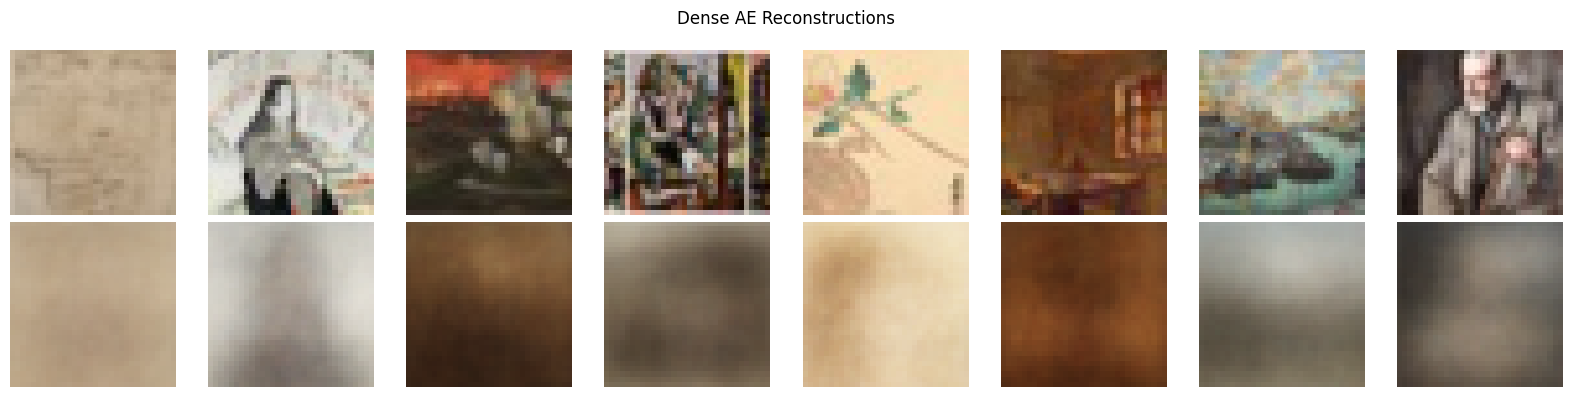

In [24]:
def show_reconstructions(model, dataloader, flatten_input, n_images=8, title="Dense AE Reconstructions"):

    """
    Visualizes the reconstruction of standard Autoencoders.
    Displays a grid with original images on the top row and reconstructed versions on the bottom.
    """

    model.eval()
    x, _, _ = next(iter(dataloader))
    x = x.to(device)
    
    # Pre-process input: flatten for Dense layers or keep 4D for Convolutional layers
    xin = x.view(x.size(0), -1) if flatten_input else x
    
    with torch.no_grad():
        out = model(xin)
    
    # If the model output was flattened (DenseAE), reshape it back to (Channels, H, W) for plotting
    if flatten_input:
        out = out.view(-1, 3, IMAGE_SIZE, IMAGE_SIZE)  # reshape back to images
    

    x = x[:n_images].cpu()
    out = out[:n_images].cpu()

    fig, axes = plt.subplots(2, n_images, figsize=(n_images * 2, 4))
    for i in range(n_images):
        # Convert (C, H, W) to (H, W, C) for imshow and clip to [0, 1] range
        axes[0, i].imshow(x[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[1, i].imshow(out[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[0,i].axis('off')
        axes[1,i].axis('off')
    axes[0,0].set_ylabel('Original', fontsize=12)
    axes[1,0].set_ylabel('Reconstructed', fontsize=12)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_reconstructions_vae(model, dataloader, n_images=8, title="VAE Reconstructions"):

    """
    Specialized visualization for Variational Autoencoders (VAEs).
    Handles the standard VAE forward pass which typically returns (reconstruction, mu, logvar).
    """

    model.eval()
    x, _, _ = next(iter(dataloader))
    x = x.to(device)
    
    with torch.no_grad():
        # VAE forward pass returns reconstruction plus latent distribution parameters
        out, _, _ = model(x)
    
    if x.dim() == 2:
        x = x.view(-1, 3, IMAGE_SIZE, IMAGE_SIZE)
    if out.dim() == 2:
        out = out.view(-1, 3, IMAGE_SIZE, IMAGE_SIZE)
    

    x = x[:n_images].cpu()
    out = out[:n_images].cpu()

    fig, axes = plt.subplots(2, n_images, figsize=(n_images * 2, 4))
    for i in range(n_images):
        axes[0, i].imshow(x[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[1, i].imshow(out[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[0,i].axis('off')
        axes[1,i].axis('off')
    axes[0,0].set_ylabel('Original', fontsize=12)
    axes[1,0].set_ylabel('Reconstructed', fontsize=12)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()



show_reconstructions(denseAE, test_loader_ae, flatten_input=True, n_images=8, title="Dense AE Reconstructions")


### Analysis of DenseAE Reconstructions
The visualization above compares the **original images** (top row) from the ArtBench-10 dataset with their **reconstructions** (bottom row) produced by the DenseAE.
#### Key Observations
- **Loss of High-Frequency Details**: The reconstructed images appear blurred. This is a classic limitation of **Dense (Fully Connected Layers)**, which treat every pixel as an independent input and fail to capture spatial informations (local patterns)
- **Mean Color Approximation**: The DenseAE tends to predice the *average* color of a specific region.
- **Global Structure**: DenseAE manages to recover the general composition (as we can see it only captures the main color of the image)

### Convolutional AutoEncoder
The **ConvAE** uses *Conv2d* and *ConvTranspose2d* layers. Instead of flattening the image immediately, it uses filters to scan the image surface

#### 1) ENCODER (Feature Extraction)
- **Input**: It preserves the 3D shape of the images
- **Convolutions**: Filters slide across the image to detect edges, textures and shapes. By using a stride of 2, the image size is reduced by a factor of 2 on each step while the feature maps increases. 

#### 2) DECODER (Upsampling)
- **Transposed Convolutions**: It uses "Deconvolutions" to reverse the shrinkage. 
- **Symmetry**: It reconstructs the resolution step-by-step (4 -> 8 -> 16 -> 32), ensuring that the spatial coherence is maintained.

In [25]:
#3 input channels and 3 output channels for RGB images
# images are 32x32x3
import torch.nn as nn
import torch.nn.functional as F

class ConvAE(nn.Module):
    def __init__(self, latent_dim=128, base_filters=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.base_filters = base_filters

        self.encoder = nn.Sequential(
            # input is (B, 3, 32, 32)
            # output after conv1: (B, 32, 16, 16)
            nn.Conv2d(3, base_filters, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(base_filters), 
            nn.ReLU(),

            # input is (B, 32, 16, 16)
            # output after conv2: (B, 64, 8, 8)
            nn.Conv2d(base_filters, base_filters*2, kernel_size=3, stride=2, padding=1),   
            nn.BatchNorm2d(base_filters*2),
            nn.ReLU(),

            # input is (B, 64, 8, 8)
            # output after conv3: (B, 128, 4, 4)
            nn.Conv2d(base_filters*2, base_filters*4, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(base_filters*4),
            nn.ReLU(),

        )

        # Latent space
        self.enc_fc = nn.Linear(base_filters*4 * 4 * 4, latent_dim)


        # Decoder: recover the image from latent space
        self.decoder_input = nn.Linear(latent_dim, base_filters*4 * 4 * 4)
        self.decoder = nn.Sequential(
            # input is (B, 128, 4, 4)
            # output after convT1: (B, 64, 8, 8)
            nn.ConvTranspose2d(base_filters*4, base_filters*2, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 8x8
            nn.ReLU(),

            # input is (B, 64, 8, 8)
            # output after convT2: (B, 3, 32, 32)
            nn.ConvTranspose2d(base_filters*2, base_filters, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 32x32
            nn.ReLU(),

            # input is (B, 32, 32, 32)
            # output after convT3: (B, 3, 64, 64)
            nn.ConvTranspose2d(base_filters, 3, kernel_size=3, stride=2, padding=1, output_padding=1),   # -> 64x64 (will be cropped to 32x32)
            nn.Sigmoid()  # output in [0,1]
        )


    def encode(self, x):
        h = self.encoder(x)

        h = h.view(h.size(0), -1)  # flatten
        z = self.enc_fc(h)
        return z

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, self.base_filters*4, 4, 4)  # reshape to (B, 128, 4, 4)
        out = self.decoder(h)
        return out
    
    def forward(self, x):
        z = self.encode(x)
        out = self.decode(z)
        return out


In [26]:
import itertools
# Try with different parameters
search_space = {
    'z': [128, 256],
    'lr': [1e-3, 5e-4],
    'filters': [32, 64, 128],
    'epochs': [20, 30],
}

keys = search_space.keys()
values = search_space.values()

combinations = list(itertools.product(*values))
print(f"Total combinations to try: {len(combinations)}")

ae_configs = []
for combo in combinations:
    # Create a dictiornary for each combination
    config = dict(zip(keys, combo))
    config['name'] = f"ConvAE_z{config['z']}_lr{config['lr']}_f{config['filters']}_e{config['epochs']}"
    ae_configs.append(config)

print("All configurations:")
for cfg in ae_configs:
    print(f" - {cfg['name']}")

Total combinations to try: 24
All configurations:
 - ConvAE_z128_lr0.001_f32_e20
 - ConvAE_z128_lr0.001_f32_e30
 - ConvAE_z128_lr0.001_f64_e20
 - ConvAE_z128_lr0.001_f64_e30
 - ConvAE_z128_lr0.001_f128_e20
 - ConvAE_z128_lr0.001_f128_e30
 - ConvAE_z128_lr0.0005_f32_e20
 - ConvAE_z128_lr0.0005_f32_e30
 - ConvAE_z128_lr0.0005_f64_e20
 - ConvAE_z128_lr0.0005_f64_e30
 - ConvAE_z128_lr0.0005_f128_e20
 - ConvAE_z128_lr0.0005_f128_e30
 - ConvAE_z256_lr0.001_f32_e20
 - ConvAE_z256_lr0.001_f32_e30
 - ConvAE_z256_lr0.001_f64_e20
 - ConvAE_z256_lr0.001_f64_e30
 - ConvAE_z256_lr0.001_f128_e20
 - ConvAE_z256_lr0.001_f128_e30
 - ConvAE_z256_lr0.0005_f32_e20
 - ConvAE_z256_lr0.0005_f32_e30
 - ConvAE_z256_lr0.0005_f64_e20
 - ConvAE_z256_lr0.0005_f64_e30
 - ConvAE_z256_lr0.0005_f128_e20
 - ConvAE_z256_lr0.0005_f128_e30


In [27]:
# --- CONVAE GRID SEARCH ---
# Dictionary to store performance history and metrics for all 24 configurations.
all_results = {}
idx = 1

# Set variables to figure out the best model
best_model_name = None
best_mse = float('inf')
# for save the weights of the best model
best_model_weights = None
# for save the history of the best model
best_model_history = None  

# Iterate through the search space (varying Latent Dim, Base Filters, and Learning Rate).
for cfg in ae_configs:
    print(f"\nCONFIGURATION: {idx}/{len(ae_configs)} === Training {cfg['name']} ===")
    idx += 1
    model = ConvAE(latent_dim=cfg['z'], base_filters=cfg['filters']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    
    # Training Phase: Executes the 20-30 epoch loop.
    # Utilizes fit_or_load_model to reuse results from Google Drive if available.
    history = fit_or_load_model(
        model=model,
        name=cfg['name'],
        train_function=train_autoencoder,
        dataloader=train_loader_ae,
        optimizer=optimizer,
        num_epochs=cfg['epochs'],
        load_if_available=True,
        flatten_input=False
    )
    
    # Quantitative Evaluation: Calculate MSE and MAE on the test subset.
    metrics = evaluate_autoencoder(model, test_loader_ae, flatten_input=False)
    all_results[cfg['name']] = {
        'history': history,
        'metrics': metrics
    }

    current_mse = metrics['mse']

    # Find the best model based on MSE
    if current_mse < best_mse:
        best_mse = current_mse
        best_model_info = cfg
        best_model_weights = model.state_dict()  # save the weights of the best model
        best_model_history = history  # save the history of the best model
    print(f"Metrics for {cfg['name']}: {metrics}")

    # Clear GPU cache between runs
    del model
    torch.cuda.empty_cache()

# --- Print the best model information ---
print("\n" + "="*30)
print(f"BEST MODEL: {best_model_info['name']}")
print(f"BEST MSE: {best_mse:.6f}")
print("="*30)

# Save the best model to Google Drive
save_model(
    model_type_name="best_ConvAE",
    weights=best_model_weights,
    history=best_model_history,
    config=best_model_info,
    overwrite=True # resave the best model every time we run the script, set to False if you want to keep the first one found
)



CONFIGURATION: 1/24 === Training ConvAE_z128_lr0.001_f32_e20 ===
Upload model "ConvAE_z128_lr0.001_f32_e20" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f32_e20.pth
Metrics for ConvAE_z128_lr0.001_f32_e20: {'mse': 0.006327127462625503, 'mae': 0.05749422928492228}

CONFIGURATION: 2/24 === Training ConvAE_z128_lr0.001_f32_e30 ===
Upload model "ConvAE_z128_lr0.001_f32_e30" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f32_e30.pth
Metrics for ConvAE_z128_lr0.001_f32_e30: {'mse': 0.0059865347901980085, 'mae': 0.056043941632906595}

CONFIGURATION: 3/24 === Training ConvAE_z128_lr0.001_f64_e20 ===
Upload model "ConvAE_z128_lr0.001_f64_e20" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f64_e20.pth
Metrics for ConvAE_z128_lr0.001_f64_e20: {'mse': 0.005997017296155294, 'mae': 0.05586657076676686}

CONFIGURATION: 4/24 === Training ConvAE_z128_lr0.001_f64_e30 ===
Upload model "ConvAE_z1

#### Computation of FID and KID for best model understading

In [33]:
# --- QUANTITATIVE EVALUATION: FID & KID ---
# N_SAMPLES: The number of images used to represent the data distribution.
N_SAMPLES = 2000
all_fid_results = {}
idx = 0

# --- PATH CONFIGURATION ---
# Centralized JSON file to persist the metrics for the Grid Search analysis.
AE_RESULTS_FILE = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/Results/convAE_results.json")

if AE_RESULTS_FILE.exists():
    with open(AE_RESULTS_FILE, "r") as f:
        all_fid_results = json.load(f)
    print(f"Obtained {len(all_fid_results)} precedent results from JSON file.")

# Collect real images from the dataset
real_images = collect_real_images_from_loader(train_loader_ae, max_images=N_SAMPLES)
real_uint8 = to_uint8_artbench10(real_images)

print("\n=== FID/KID Evaluation ===")
for cfg in ae_configs:
    idx += 1
    print(f"\n CONFIGURATION: {idx}/{len(ae_configs)} -- Evaluating {cfg['name']} ---")

    # Initialize the specific architecture from the Grid Search space.
    model = ConvAE(latent_dim=cfg['z'], base_filters=cfg['filters']).to(device)
    
    # Load the pre-trained weights from Drive (no training performed here).
    fit_or_load_model(
        model=model,
        name=cfg['name'],
        train_function= None,
        load_if_available=True
    )

    # 3. GENERATION: Produce reconstructions for the evaluation set.
    gen_images = sample_from_AE(model, train_loader_ae, images=N_SAMPLES)
    # Convert to uint8 [0, 255] as required by the Inception-v3 feature extractor.
    gen_uint8 = to_uint8_artbench10(gen_images)

    # 4. METRIC COMPUTATION: Calculate the statistical distance between distributions.
    # FID measures feature distance (lower is better).
    # KID measures squared maximum mean discrepancy (lower is better).
    fid_val, kid_val = compute_fid(real_uint8, gen_uint8)
    
    # Update the JSON file immediately after each configuration to prevent data loss.
    update_results_json(AE_RESULTS_FILE, cfg['name'], fid_val, kid_val)
    
    all_fid_results[cfg['name']] = {
        'fid': fid_val,
        'kid': kid_val
    }

    del model
    torch.cuda.empty_cache()

# --- # --- FINAL RESULTS SUMMARY --- ---
print("\n" + "="*60)
print(f"{'CONFIGURATION':<25} | {'FID (↓)':<10} | {'KID (↓)':<10}")
print("-" * 60)
for name, res in all_fid_results.items():
    print(f"{name:<25} | {res['fid']:>10.2f} | {res['kid']:>10.4f}")
print("="*60)


Obtained 24 precedent results from JSON file.

=== FID/KID Evaluation ===

 CONFIGURATION: 1/24 -- Evaluating ConvAE_z128_lr0.001_f32_e20 ---
Upload model "ConvAE_z128_lr0.001_f32_e20" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f32_e20.pth


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation mig

Results for 'ConvAE_z128_lr0.001_f32_e20' saved in: convAE_results.json

 CONFIGURATION: 2/24 -- Evaluating ConvAE_z128_lr0.001_f32_e30 ---
Upload model "ConvAE_z128_lr0.001_f32_e30" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f32_e30.pth
Results for 'ConvAE_z128_lr0.001_f32_e30' saved in: convAE_results.json

 CONFIGURATION: 3/24 -- Evaluating ConvAE_z128_lr0.001_f64_e20 ---
Upload model "ConvAE_z128_lr0.001_f64_e20" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f64_e20.pth
Results for 'ConvAE_z128_lr0.001_f64_e20' saved in: convAE_results.json

 CONFIGURATION: 4/24 -- Evaluating ConvAE_z128_lr0.001_f64_e30 ---
Upload model "ConvAE_z128_lr0.001_f64_e30" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f64_e30.pth
Results for 'ConvAE_z128_lr0.001_f64_e30' saved in: convAE_results.json

 CONFIGURATION: 5/24 -- Evaluating ConvAE_z128_lr0.001_f128_e20 ---
Upload model "ConvAE_z128

#### Quantitative Analysis: ConvAE Hyperparameter Grid Search
The table above summarizes the performance of various **ConvAE** configurations on the ArtBench-10 dataset. The evaluation is based on two primary generative metrics: **FID** and **KID**. 
- **Inpact of the Latent Dimension** $z$: There is a clear performance "step" when moving from $z = 128$ to $z = 256$. The models with a larger latent space achieve *lower* FID scores. This suggests that the stylistic complexity of ArtBench-10 requires a higher-dimensional bottleneck to preserve sufficient structural information.
- **Optimal Filter Count** $f$: Increasing the filters from $32$ to $64$ provided a significant boost in reconstruction quality. Interestingly, increasing filters further to 128 did not always yield better results within the 30-epoch budget.
- **Learning Rate** $lr$: A learning rate of $0.001$ outperform $0.0005$ across all tests. This confirms that the higher learning rate allowed the Adam optimizer to navigate the loss landscape more effectively within the given timeframe.
- **Training Duration** $e$: The consistent improvement from $20$ to $30$ epochs indicates that the models were still learning! Greater epochs would likely yield even lower FID scores.

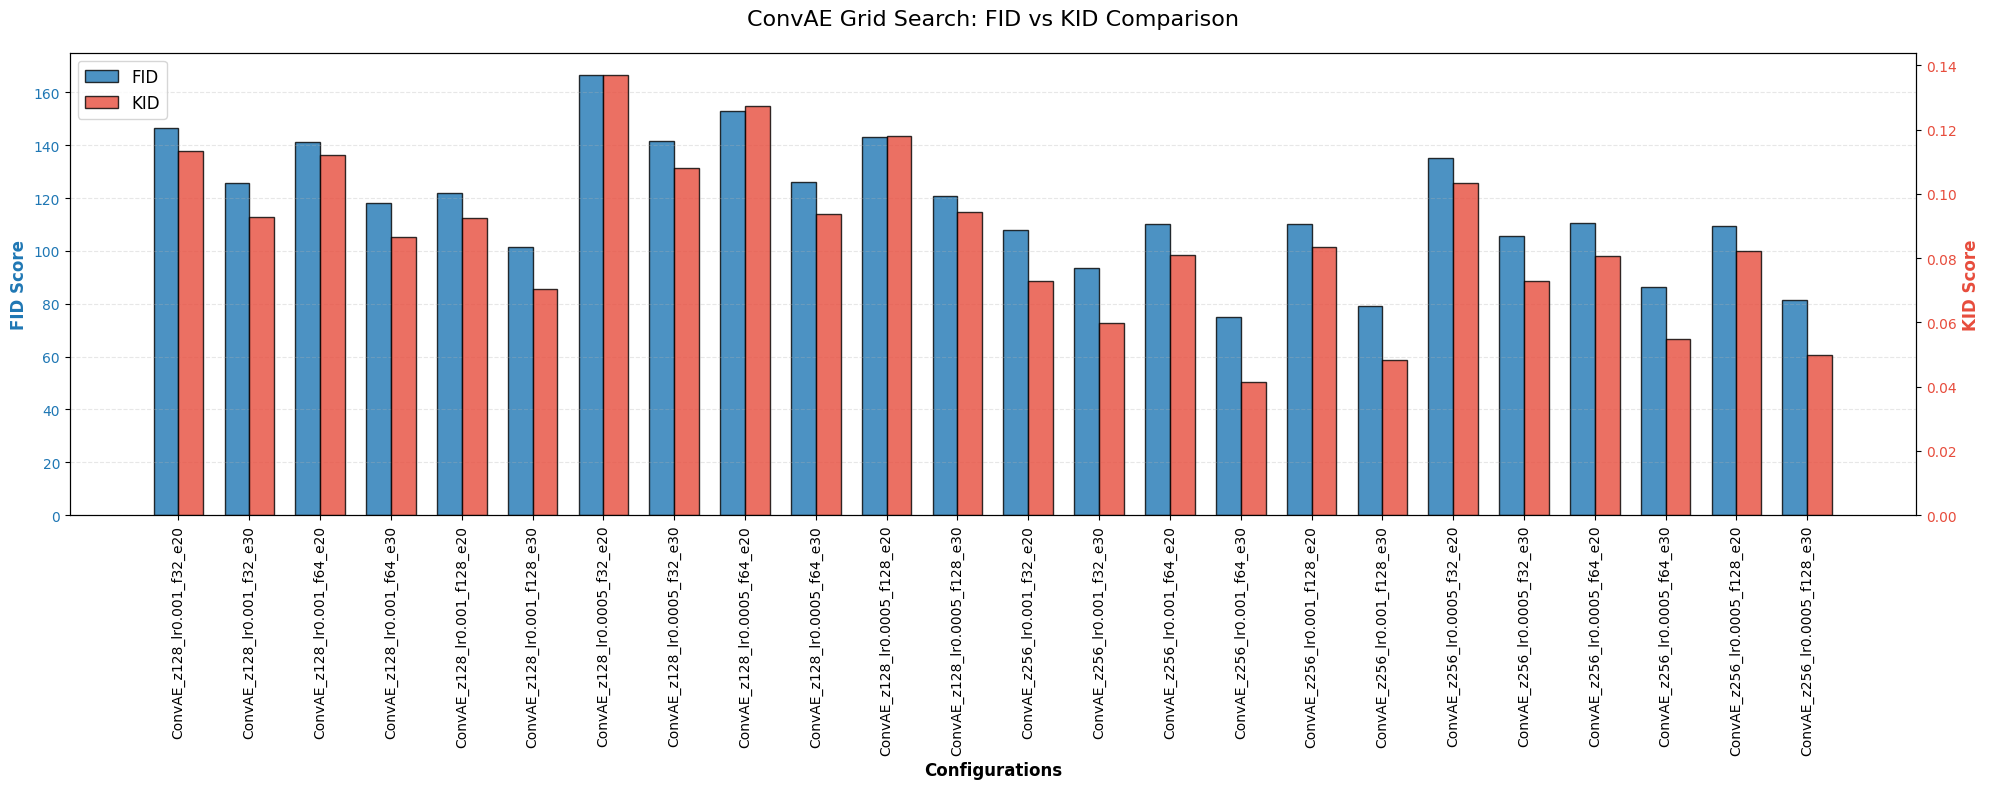

In [34]:
def plot_fid_kid_comparison(dict):

    """
    Generates a dual-axis bar chart to compare FID and KID metrics across different configurations.
    """

    # Maintain the original order of configurations for consistent plotting
    names = list(dict.keys())
    fid_values = [dict[name]['fid'] for name in names]
    kid_values = [dict[name]['kid'] for name in names]
    
    x = np.arange(len(names))  
    width = 0.35              

    fig, ax1 = plt.subplots(figsize=(20, 8))

    # --- LEFT AXIS: FID SCORE ---
    color_fid = '#1f77b4' # Blu
    rects1 = ax1.bar(x - width/2, fid_values, width, label='FID', color=color_fid, edgecolor='black', alpha=0.8)
    ax1.set_ylabel('FID Score', color=color_fid, fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_fid)
    
    # --- RIGHT AXIS: KID SCORE ---
    ax2 = ax1.twinx() 
    color_kid = '#e74c3c'
    rects2 = ax2.bar(x + width/2, kid_values, width, label='KID', color=color_kid, edgecolor='black', alpha=0.8)
    ax2.set_ylabel('KID Score', color=color_kid, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_kid)

    # --- AXIS CONFIGURATION ---
    ax1.set_xticks(x)
    ax1.set_xticklabels(names, rotation=90, fontsize=10)
    ax1.set_xlabel('Configurations', fontsize=12, fontweight='bold')
    
    plt.title('ConvAE Grid Search: FID vs KID Comparison', fontsize=16, pad=20)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12)

    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    fig.tight_layout()
    plt.show()

plot_fid_kid_comparison(all_fid_results)

### Comparison plot - ConvAE
I make a comparison between:
- real images
- best model
- worst model

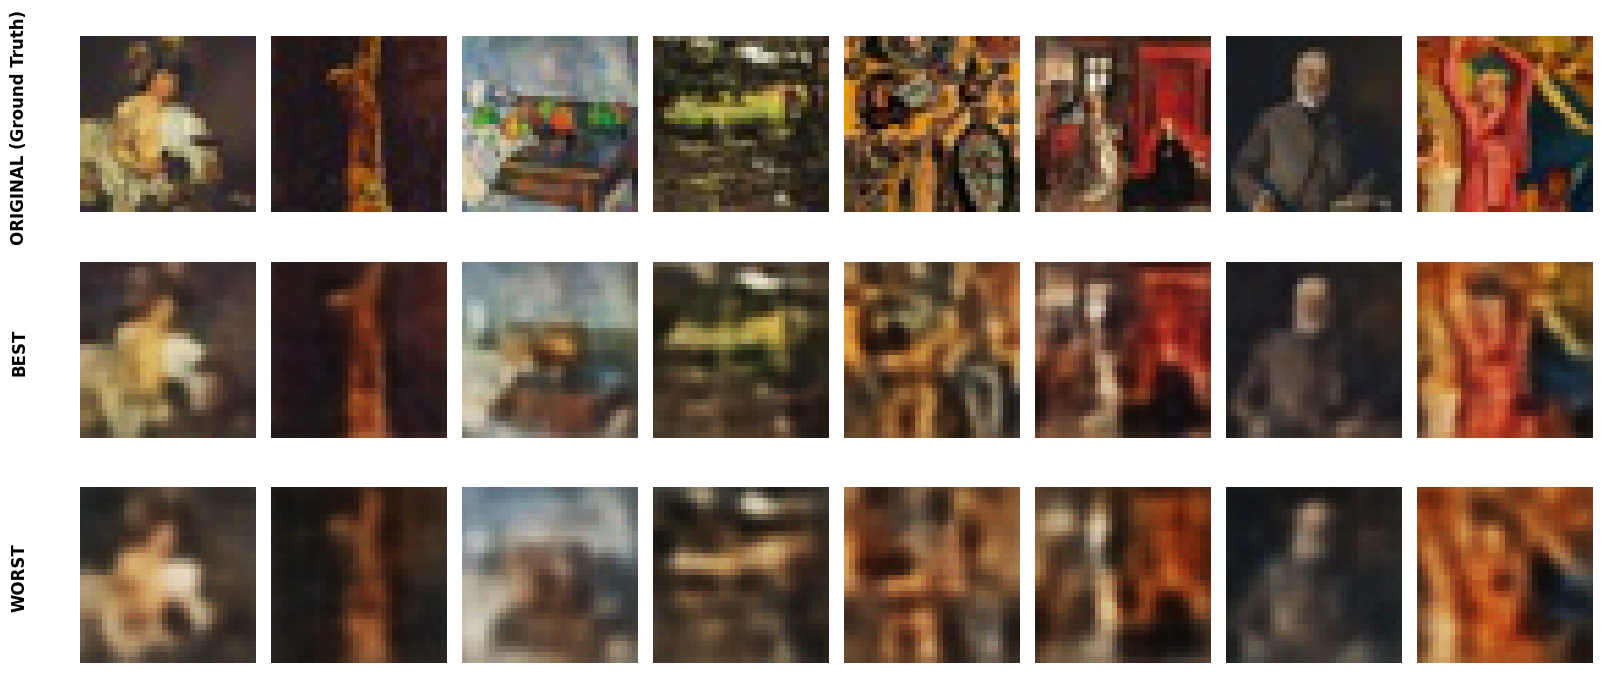

In [35]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def triple_visual_comparison(best_model, worst_model, loader, n_images=8, device="cuda"):
    
    """
    Compare original images with reconstructions from the best and worst trained ConvAE
    """
    
    best_model.eval()
    worst_model.eval()
    
    # Take a batch of real images
    images, _, _ = next(iter(loader))
    images = images[:n_images].to(device)
    
    with torch.no_grad():
        # Best reconstruction
        encoded_best = best_model.encode(images)
        reconst_best = best_model.decode(encoded_best)
        
        # Worst reconstruction
        encoded_worst = worst_model.encode(images)
        reconst_worst = worst_model.decode(encoded_worst)
            
    # Conversion for plotting (from Tensor to Numpy HxWxC)
    def to_np(img_tensor):
        img = img_tensor.cpu().numpy().transpose(0, 2, 3, 1)
        return np.clip(img, 0, 1)

    real_np = to_np(images)
    best_np = to_np(reconst_best)
    worst_np = to_np(reconst_worst)

    # Create the plot
    fig, axes = plt.subplots(nrows=3, ncols=n_images, figsize=(n_images * 2, 7))
    
    titles = ["ORIGINAL (Ground Truth)", "BEST", "WORST"]
    data = [real_np, best_np, worst_np]

    for row in range(3):
        for col in range(n_images):
            axes[row, col].imshow(data[row][col])
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].text(-10, 16, titles[row], rotation=90, 
                                   va='center', ha='right', fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.show()


best_cfg, _ = load_model_from_drive("best_ConvAE")
best_model = ConvAE(latent_dim=best_cfg['z'], base_filters=best_cfg['filters']).to(device)
best_model.load_state_dict(torch.load('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/best_ConvAE.pth'))

worst_model = ConvAE(latent_dim=128, base_filters=32).to(device)
worst_model.load_state_dict(torch.load('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_0005_f32_e20.pth'))
triple_visual_comparison(best_model, worst_model, train_loader_from_csv, n_images=8, device=device)

-----------------------------------------------------------------------------------------------------------------------------------------------------------

### VARIATIONAL AUTOENCODERS

In [36]:
class ConvVAE(nn.Module):
    """
    Convolutional Variational Autoencoder (ConvVAE) for ArtBench-10.
    This model maps inputs to a latent distribution rather than a fixed point, 
    allowing for smoother interpolation and image generation.
    """

    def __init__(self, latent_dim=128, base_filters=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.base_filters = base_filters

        # ENCODER
        # Uses a stride of 2 to reduce spatial dimensions while increasing channel depth
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, base_filters, 3, stride=2, padding=1),  # -> 16x16
            nn.BatchNorm2d(base_filters), 
            nn.ReLU(),
            nn.Conv2d(base_filters, base_filters*2, 3, stride=2, padding=1), # -> 8x8
            nn.BatchNorm2d(base_filters*2), 
            nn.ReLU(),
            nn.Conv2d(base_filters*2, base_filters*4, 3, stride=2, padding=1),# -> 4x4
            nn.BatchNorm2d(base_filters*4), 
            nn.ReLU(),
        )

        # LATENT SPACE 
        self.fc_mu = nn.Linear(base_filters*4 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(base_filters*4 * 4 * 4, latent_dim)

        # DECODER
        # Projects the latent vector back to spatial dimensions and upsamples to 32x32
        self.decoder_input = nn.Linear(latent_dim, base_filters*4 * 4 * 4)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(base_filters*4, base_filters*2, 3, stride=2, padding=1, output_padding=1), # -> 8x8
            nn.BatchNorm2d(base_filters*2), 
            nn.ReLU(),
            nn.ConvTranspose2d(base_filters*2, base_filters, 3, stride=2, padding=1, output_padding=1),  # -> 16x16
            nn.BatchNorm2d(base_filters), 
            nn.ReLU(),
            nn.ConvTranspose2d(base_filters, 3, 3, stride=2, padding=1, output_padding=1),   # -> 32x32
            nn.Sigmoid() # output to [0,1]
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def encode(self, x):
        """Maps input image to latent distribution parameters (mu, logvar)."""
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)  # flatten
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def decode(self, z):
        """Reconstructs the image from a sampled latent vector z."""
        h = self.decoder_input(z)
        h = h.view(-1, self.base_filters*4, 4, 4)  # reshape to (B, 128, 4, 4)
        out = self.decoder_conv(h)
        return out
    
    def forward(self, x):
        """
        Full VAE pass: Encode -> Reparameterize -> Decode.
        Returns the reconstruction along with mu and logvar for KL-divergence calculation.
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        out = self.decode(z)
        return out, mu, logvar

Insert the dynamic variable for configurations

In [38]:
def vae_loss_function(recon_x, x, mu, logvar, beta = 1.0):
    
    # Reconstruction Loss: Measures how well the model reconstructs the input image.
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL Divergence: Acts as a regularizer, pushing the latent distribution toward N(0, 1)[cite: 74, 83].
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total Loss: Combines the two objectives using the 'beta' hyperparameter.
    total_loss = (recon_loss + beta * kl_loss)/x.size(0)  # normalized by batch size
    
    return total_loss, recon_loss/x.size(0), kl_loss/x.size(0)

### Training Loop for VAE

In [39]:
def train_vae(model, dataloader, optimizer, beta = 0.7, num_epochs=20):
    
    history = {
        'total_loss': [],
        'recon_loss': [],
        'kl_loss': []
    }
    
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        train_recon_loss = 0
        train_kl_loss = 0
        for x, _, _ in dataloader:
            x = x.to(device)

            # The model returns the reconstruction, latent mean (mu), and log-variance
            recon_x, mu, logvar = model(x)

            # LOSS CALCULATION
            # Compute the weighted ELBO (Evidence Lower Bound) loss
            loss, recon_loss, kl_loss = vae_loss_function(recon_x, x, mu, logvar, beta=beta)

            #Backpropagation and update weights
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0) 
            train_recon_loss += recon_loss.item() * x.size(0)
            train_kl_loss += kl_loss.item() * x.size(0)
        
        n = len(dataloader.dataset)
        avg_total = total_loss / n
        avg_recon = train_recon_loss / n
        avg_kl = train_kl_loss / n

        history['total_loss'].append(avg_total)
        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_total:.4f} (Recon: {avg_recon:.4f}, KL: {avg_kl:.4f})")
    
    return history


In [40]:
def evaluate_vae(model, dataloader, beta=0.7):

    """
    Evaluates the VAE's performance on a validation or test set.
    """

    model.eval()
    total_loss = 0.0
    recon_loss = 0.0
    kl_loss = 0.0
    mse = 0.0
    mae = 0.0
    n = 0

    # Disable gradient calculations for efficient inference
    with torch.no_grad():
        for x, _, _ in dataloader:
            x = x.to(device)
            
            # Forward pass: obtain reconstruction and latent parameters
            recon_x, mu, logvar = model(x)

            # PROBABILISTIC LOSS EVALUATION
            # Evaluates how well the model follows the VAE objective
            loss, recon, kl = vae_loss_function(recon_x, x, mu, logvar, beta=beta)

            total_loss += loss.item() * x.size(0)
            recon_loss += recon.item() * x.size(0)
            kl_loss += kl.item() * x.size(0)

            mse += F.mse_loss(recon_x, x, reduction='sum').item()
            mae += F.l1_loss(recon_x, x, reduction='sum').item()


            n += x.size(0)

    numel = x[0].numel()  # number of elements per image
    return {
        'total_loss': total_loss / n,
        'recon_loss': recon_loss / n,
        'kl_loss': kl_loss / n,
        'mse': mse / (n * numel),
        'mae': mae / (n * numel)
    }
    

In [41]:
# --- CONVVAE HYPERPARAMETER GRID SEARCH ---
# Defining the search space to optimize the balance between reconstruction and diversity.
vae_search_space = {
    'z': [128, 256],      # Latent dimension: determines the compression bottleneck
    'lr': [1e-3, 5e-4],   # Learning rates to find stable convergence for the loss
    'filters': [32, 64],  # Base filter depth for the convolutional layers
    'epochs': [20],
    'beta': [0.1, 0.5, 0.7, 1.0] # Beta: controls the trade-off between MSE and KL-divergence
}

# Generation of the configurations to try
keys = vae_search_space.keys()
values = vae_search_space.values()
combinations = list(itertools.product(*values))
vae_configs = []
for combo in combinations:
    config = dict(zip(keys, combo))
    config['name'] = f"ConvVAE_z{config['z']}_lr{config['lr']}_f{config['filters']}_e{config['epochs']}_b{config['beta']}"
    vae_configs.append(config)

print(f"Ready to test {len(vae_configs)} VAE configurations:")
print("All VAE configurations:")
for cfg in vae_configs:
    print(f" - {cfg['name']}")


Ready to test 32 VAE configurations:
All VAE configurations:
 - ConvVAE_z128_lr0.001_f32_e20_b0.1
 - ConvVAE_z128_lr0.001_f32_e20_b0.5
 - ConvVAE_z128_lr0.001_f32_e20_b0.7
 - ConvVAE_z128_lr0.001_f32_e20_b1.0
 - ConvVAE_z128_lr0.001_f64_e20_b0.1
 - ConvVAE_z128_lr0.001_f64_e20_b0.5
 - ConvVAE_z128_lr0.001_f64_e20_b0.7
 - ConvVAE_z128_lr0.001_f64_e20_b1.0
 - ConvVAE_z128_lr0.0005_f32_e20_b0.1
 - ConvVAE_z128_lr0.0005_f32_e20_b0.5
 - ConvVAE_z128_lr0.0005_f32_e20_b0.7
 - ConvVAE_z128_lr0.0005_f32_e20_b1.0
 - ConvVAE_z128_lr0.0005_f64_e20_b0.1
 - ConvVAE_z128_lr0.0005_f64_e20_b0.5
 - ConvVAE_z128_lr0.0005_f64_e20_b0.7
 - ConvVAE_z128_lr0.0005_f64_e20_b1.0
 - ConvVAE_z256_lr0.001_f32_e20_b0.1
 - ConvVAE_z256_lr0.001_f32_e20_b0.5
 - ConvVAE_z256_lr0.001_f32_e20_b0.7
 - ConvVAE_z256_lr0.001_f32_e20_b1.0
 - ConvVAE_z256_lr0.001_f64_e20_b0.1
 - ConvVAE_z256_lr0.001_f64_e20_b0.5
 - ConvVAE_z256_lr0.001_f64_e20_b0.7
 - ConvVAE_z256_lr0.001_f64_e20_b1.0
 - ConvVAE_z256_lr0.0005_f32_e20_b0.1
 - Co

In [42]:
# DATA LOADING FOR VARATIONAL AUTOENCODER (VAE)
# We use use_gan_norm=False to ensure images are in the [0, 1] range.
# For the exploratory phase, we use the 20% stratified subset (train_ids_from_csv).
train_loader_vae, test_loader_vae = build_artbench_loaders(
    train_hf,
    test_hf,
    batch_size=BATCH_SIZE,
    use_gan_norm=False,
    train_ids=train_ids_from_csv,
    image_size=IMAGE_SIZE
)


# --- VAE GRID SEARCH ---
# Dictionary to store results for each VAE configuration
all_vae_results = {}
idx = 1

# Performance tracking variables for the "Best Model" selection
best_vae_name = None
best_vae_loss = float('inf')
best_vae_weights = None
best_vae_history = None
best_vae_info = None

for cfg in vae_configs: # Usiamo la lista vae_configs che abbiamo appena sistemato
    print(f"\nVAE CONFIGURATION: {idx}/{len(vae_configs)} === Training {cfg['name']} ===")
    idx += 1
    
    # MODEL INITIALIZATION
    model = ConvVAE(latent_dim=cfg['z'], base_filters=cfg['filters']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    
    # TRAINING or LOADING
    history = fit_or_load_model(
        model=model,
        name=cfg['name'],
        train_function=train_vae,
        dataloader=train_loader_vae,
        optimizer=optimizer,
        num_epochs=cfg['epochs'],
        beta=cfg['beta'],           # Hyperparameter controlling KL-Divergence regularization
        load_if_available=True,    
    )
    
    # QUANTITATIVE EVALUATION
    # Compute metrics on the test set (MSE and KL components)
    metrics = evaluate_vae(model, test_loader_vae, beta=cfg['beta']) 
    
    all_vae_results[cfg['name']] = {
        'history': history,
        'metrics': metrics,
        'config': cfg
    }

    # Evaluation focuses on the MSE component
    current_mse = metrics['mse']

    # Update the global best model if current MSE is lower
    if current_mse < best_vae_loss:
        best_vae_loss = current_mse
        best_vae_info = cfg
        best_vae_weights = model.state_dict()
        best_vae_history = history
        
    print(f"Metrics for {cfg['name']}: {metrics}")

    # Clear GPU cache to prevent memory fragmentation during extensive grid search (32+ runs)
    del model
    torch.cuda.empty_cache()

# --- FINAL RANKING VAE ---
print("\n" + "="*40)
print(f"BEST VAE MODEL: {best_vae_info['name']}")
print(f"Best MSE Reconstruction: {best_vae_loss:.6f}")
print(f"Beta: {best_vae_info['beta']}")
print("="*40)

# Save the best model to Google Drive
save_model(
    model_type_name="best_ConvVAE",
    weights=best_vae_weights,
    history=best_vae_history,
    config=best_vae_info
)



Preprocessing: using AE/VAE normalization ([0,1])
Notebook kernel detected: forcing num_workers=0 for DataLoader stability.

VAE CONFIGURATION: 1/32 === Training ConvVAE_z128_lr0.001_f32_e20_b0.1 ===
Upload model "ConvVAE_z128_lr0.001_f32_e20_b0.1" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f32_e20_b0_1.pth
Metrics for ConvVAE_z128_lr0.001_f32_e20_b0.1: {'total_loss': 36.566884753417966, 'recon_loss': 26.685943954467774, 'kl_loss': 98.80940493164063, 'mse': 0.008686830714344979, 'mae': 0.0687599057038625}

VAE CONFIGURATION: 2/32 === Training ConvVAE_z128_lr0.001_f32_e20_b0.5 ===
Upload model "ConvVAE_z128_lr0.001_f32_e20_b0.5" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f32_e20_b0_5.pth
Metrics for ConvVAE_z128_lr0.001_f32_e20_b0.5: {'total_loss': 58.19631063232422, 'recon_loss': 43.59220095214844, 'kl_loss': 29.208219342041016, 'mse': 0.014190169580777486, 'mae': 0.08946184415817261}

VAE CONFIGURATION: 

In [43]:
# --- QUANTITATIVE EVALUATION: FID AND KID BENCHMARKING ---

# Number of samples used for statistical distribution comparison
N_SAMPLES = 2000
all_fid_results = {}
idx = 0

# Persistent storage for evaluation metrics to ensure reproducibility
VAE_RESULTS_FILE = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/Results/convVAE_results.json")

# Load existing results to avoid redundant computations
if VAE_RESULTS_FILE.exists():
    with open(VAE_RESULTS_FILE, "r") as f:
        all_fid_results = json.load(f)
    print(f"Recovered {len(all_fid_results)} previous results from JSON file.")

# REFERENCE DISTRIBUTION: Collect real images from the dataset as Ground Truth
# These images are converted to uint8 format for standard Inception-v3 feature extraction
real_images = collect_real_images_from_loader(train_loader_vae, max_images=N_SAMPLES)
real_uint8 = to_uint8_artbench10(real_images)

print("\n=== FID/KID Evaluation ===")
for cfg in vae_configs:
    idx += 1
    print(f"\n CONFIGURATION: {idx}/{len(vae_configs)} -- Evaluating {cfg['name']} ---")

    model = ConvVAE(latent_dim=cfg['z'], base_filters=cfg['filters']).to(device)
    fit_or_load_model(
        model=model,
        name=cfg['name'],
        train_function= None,
        load_if_available=True
    )

    # Samples are drawn from the learned latent space prior distribution p(z) = N(0, I)
    gen_images = sample_from_VAE(model, images=N_SAMPLES)
    gen_uint8 = to_uint8_artbench10(gen_images)

    # METRIC COMPUTATION
    fid_val, kid_val = compute_fid(real_uint8, gen_uint8)
    
    # Update the centralized JSON file with the newly computed metrics
    update_results_json(VAE_RESULTS_FILE, cfg['name'], fid_val, kid_val)

    all_fid_results[cfg['name']] = {
        'fid': fid_val,
        'kid': kid_val
    }

    del model
    torch.cuda.empty_cache()

# --- FINAL TABULAR SUMMARY ---
print("\n" + "="*60)
print(f"{'CONFIGURATION':<25} | {'FID (↓)':<10} | {'KID (↓)':<10}")
print("-" * 60)
for name, res in all_fid_results.items():
    print(f"{name:<25} | {res['fid']:>10.2f} | {res['kid']:>10.4f}")
print("="*60)


Recovered 32 previous results from JSON file.

=== FID/KID Evaluation ===

 CONFIGURATION: 1/32 -- Evaluating ConvVAE_z128_lr0.001_f32_e20_b0.1 ---
Upload model "ConvVAE_z128_lr0.001_f32_e20_b0.1" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f32_e20_b0_1.pth


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Results for 'ConvVAE_z128_lr0.001_f32_e20_b0.1' saved in: convVAE_results.json

 CONFIGURATION: 2/32 -- Evaluating ConvVAE_z128_lr0.001_f32_e20_b0.5 ---
Upload model "ConvVAE_z128_lr0.001_f32_e20_b0.5" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f32_e20_b0_5.pth
Results for 'ConvVAE_z128_lr0.001_f32_e20_b0.5' saved in: convVAE_results.json

 CONFIGURATION: 3/32 -- Evaluating ConvVAE_z128_lr0.001_f32_e20_b0.7 ---
Upload model "ConvVAE_z128_lr0.001_f32_e20_b0.7" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f32_e20_b0_7.pth
Results for 'ConvVAE_z128_lr0.001_f32_e20_b0.7' saved in: convVAE_results.json

 CONFIGURATION: 4/32 -- Evaluating ConvVAE_z128_lr0.001_f32_e20_b1.0 ---
Upload model "ConvVAE_z128_lr0.001_f32_e20_b1.0" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f32_e20_b1_0.pth
Results for 'ConvVAE_z128_lr0.001_f32_e20_b1.0' saved in: convVAE_results.json

 CONFIGURAT

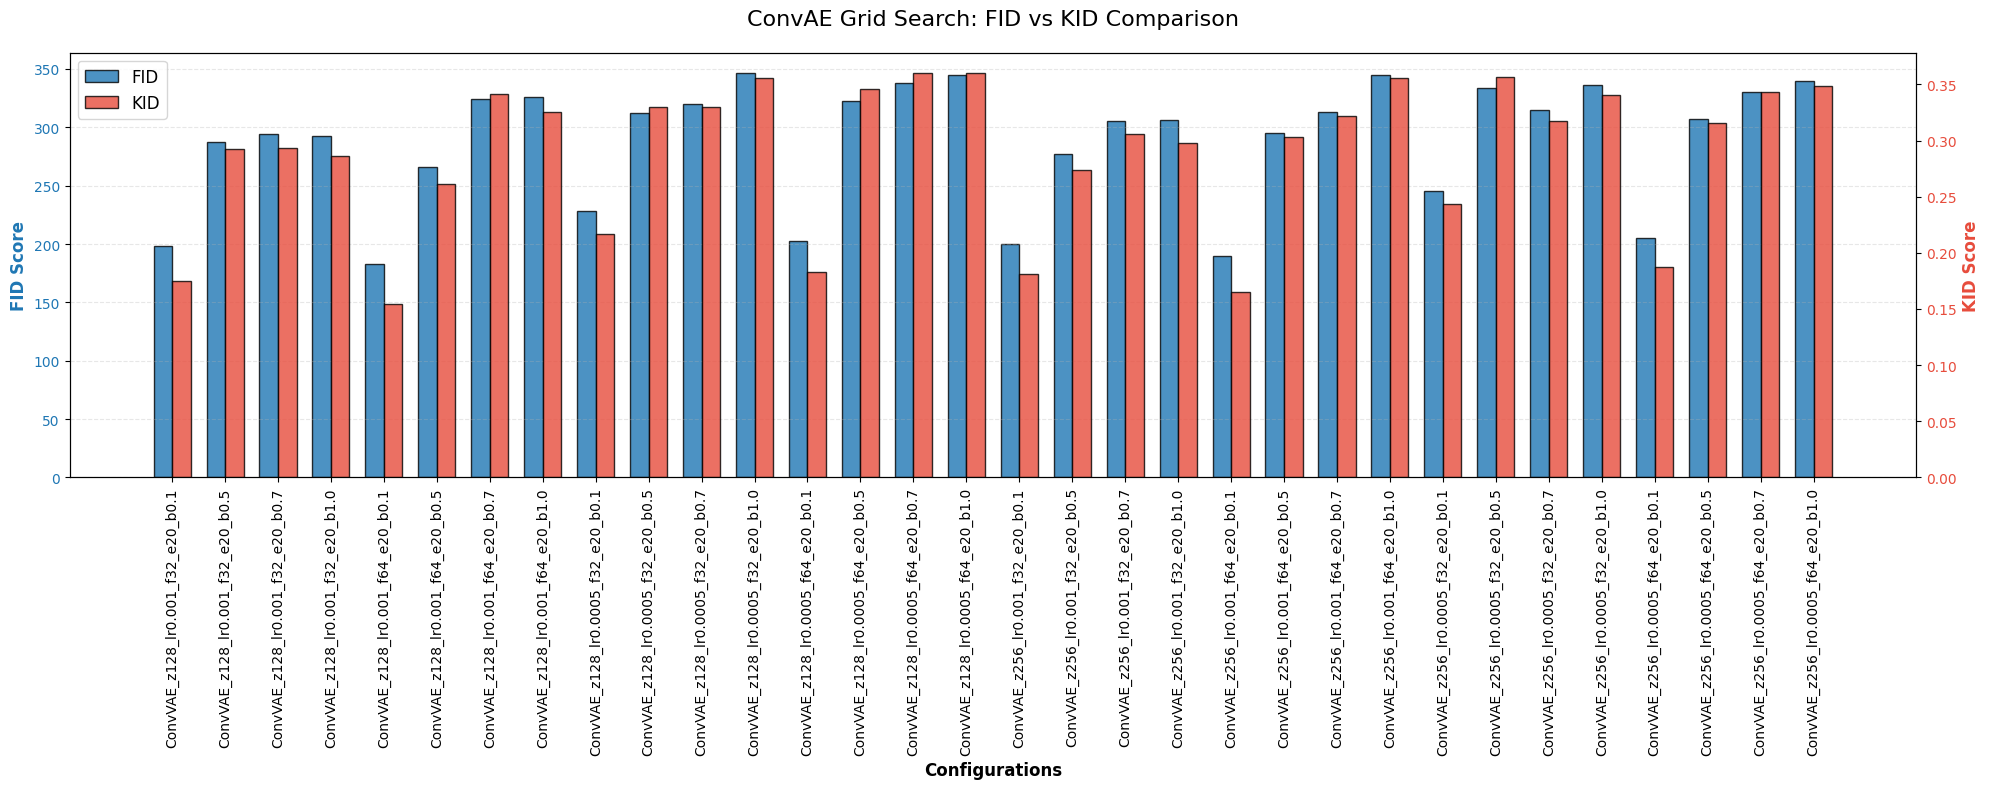

In [44]:
plot_fid_kid_comparison(all_fid_results)

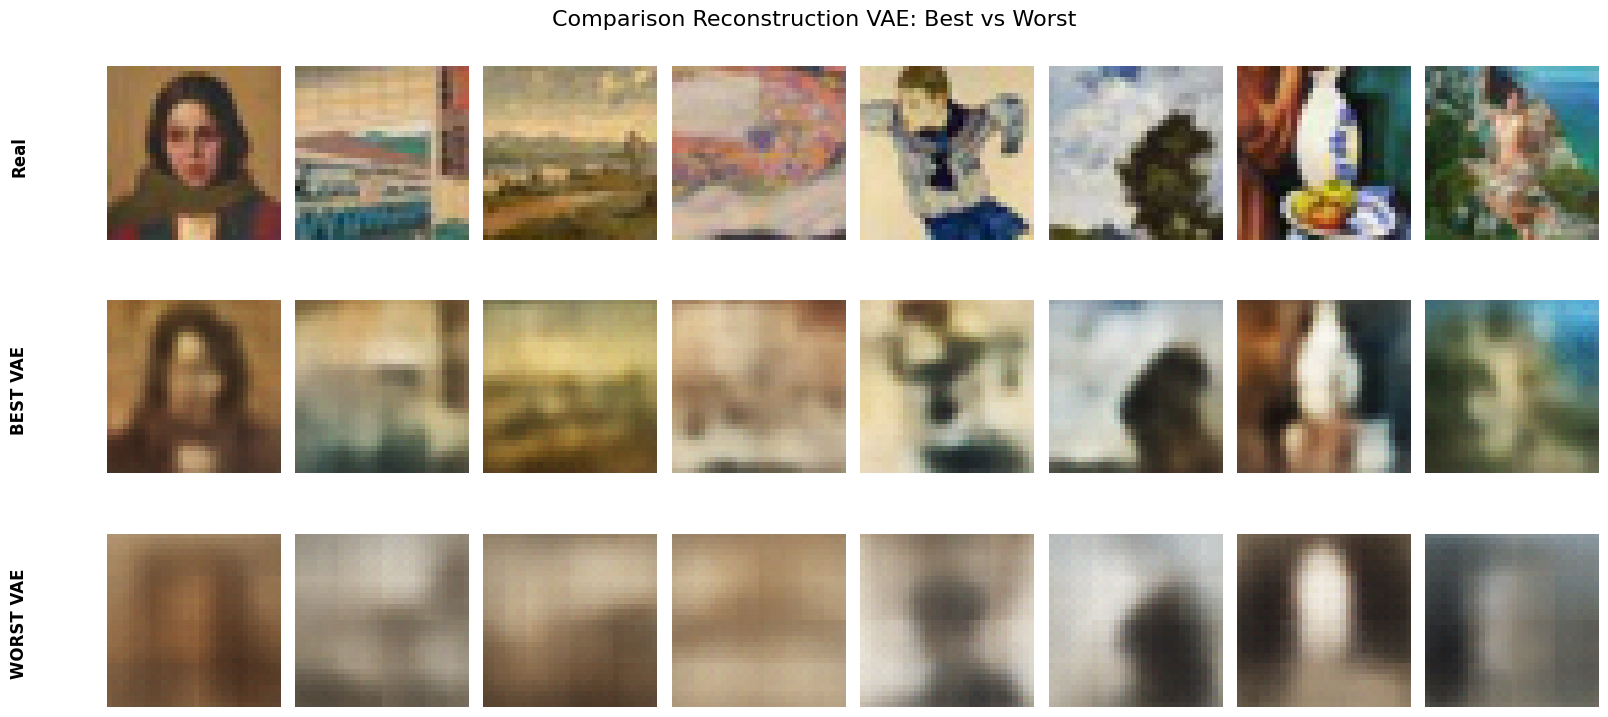

In [45]:
def triple_visual_comparison_vae(best_vae, worst_vae, loader, n_images=8, device="cuda"):
    best_vae.eval()
    worst_vae.eval()
    
    # Take a batch of real images 
    batch = next(iter(loader))
    images = batch[0][:n_images].to(device)
    
    with torch.no_grad():
        # Best ConvVAE
        # VAE returns (recon, mu, logvar)
        reconst_best, _, _ = best_vae(images)
        
        # Worst ConvVAE
        reconst_worst, _, _ = worst_vae(images)
            
    # Utility function to convert tensors into numpy images
    def to_np(img_tensor):
        img = img_tensor.cpu().numpy().transpose(0, 2, 3, 1)
        return np.clip(img, 0, 1)

    real_np = to_np(images)
    best_np = to_np(reconst_best)
    worst_np = to_np(reconst_worst)

    # Create the plot (3 subplots)
    fig, axes = plt.subplots(nrows=3, ncols=n_images, figsize=(n_images * 2, 8))
    
    titles = ["Real", "BEST VAE", "WORST VAE"]
    data = [real_np, best_np, worst_np]

    for row in range(3):
        for col in range(n_images):
            axes[row, col].imshow(data[row][col])
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].text(-15, 16, titles[row], rotation=90, 
                                   va='center', ha='right', fontweight='bold', fontsize=12)

    plt.suptitle("Comparison Reconstruction VAE: Best vs Worst", fontsize=16, y=0.95)
    plt.tight_layout()
    plt.show()


best_cfg_vae, _ = load_model_from_drive("best_ConvVAE")
best_vae = ConvVAE(latent_dim=best_cfg_vae['z'], base_filters=best_cfg_vae['filters']).to(device)
best_vae.load_state_dict(torch.load('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/best_ConvVAE.pth'))

worst_vae = ConvVAE(latent_dim=256, base_filters=64).to(device)
worst_vae.load_state_dict(torch.load('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z256_lr0_001_f64_e20_b1_0.pth'))

triple_visual_comparison_vae(best_vae, worst_vae, train_loader_from_csv, n_images=8, device=device)

### Best AE vs Best VAE

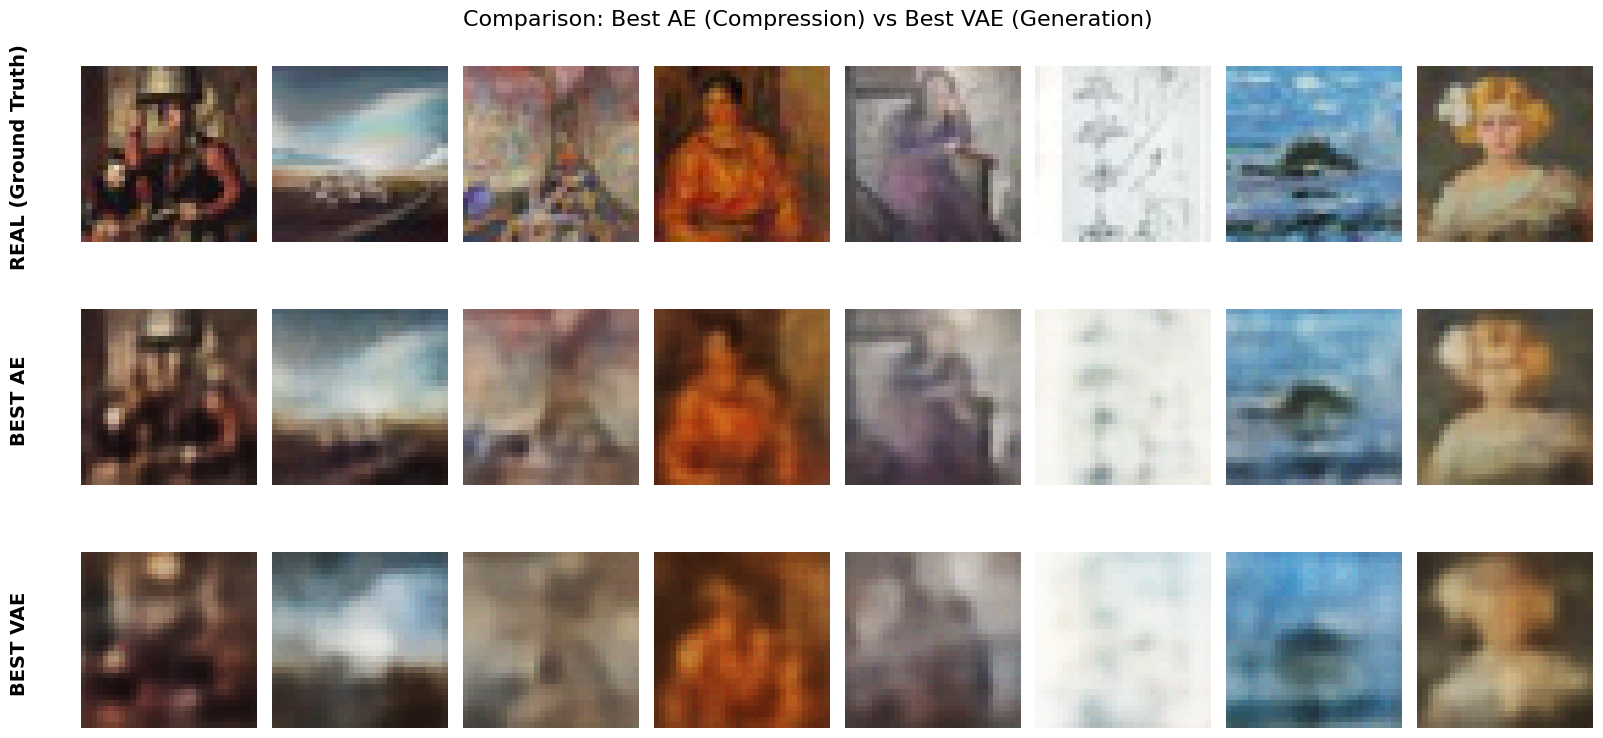

In [46]:
def compare_best_ae_vae(best_ae, best_vae, loader, n_images=8, device="cuda"):
    
    """
    Visual comparison of reconstruction fidelity between the top-performing 
    Autoencoder (AE) and Variational Autoencoder (VAE).
    Purpose: To analyze blurriness vs. structural preservation in the latent bottleneck.
    """

    best_ae.eval()
    best_vae.eval()
    
    # Extract a batch of real images from the dataset loader
    batch = next(iter(loader))
    images = batch[0][:n_images].to(device)
    
    with torch.no_grad():
        # AE RECONSTRUCTION (Deterministic Mapping)
        reconst_ae = best_ae(images)
        
        # 3. VAE RECONSTRUCTION (Stochastic Mapping)
        reconst_vae, _, _ = best_vae(images)
            
    # Convert PyTorch tensors back to Numpy format for Matplotlib visualization
    def to_np(img_tensor):
        img = img_tensor.cpu().numpy().transpose(0, 2, 3, 1)
        return np.clip(img, 0, 1)

    real_np = to_np(images)
    ae_np = to_np(reconst_ae)
    vae_np = to_np(reconst_vae)

    # 4. Plotting
    fig, axes = plt.subplots(nrows=3, ncols=n_images, figsize=(n_images * 2, 8))
    
    titles = ["REAL (Ground Truth)", "BEST AE", "BEST VAE"]
    data = [real_np, ae_np, vae_np]

    for row in range(3):
        for col in range(n_images):
            axes[row, col].imshow(data[row][col])
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].text(-10, 16, titles[row], rotation=90, 
                                   va='center', ha='right', fontweight='bold', 
                                   fontsize=14, color='black')

    plt.suptitle("Comparison: Best AE (Compression) vs Best VAE (Generation)", fontsize=16, y=0.95)
    plt.tight_layout()
    plt.show()

compare_best_ae_vae(best_model, best_vae, train_loader_from_csv, n_images=8, device=device)

### Comparative Analysis: Reconstruction Performance (AE vs. VAE)
#### 1. Visual Fidelity and Sharpness (AE Advantage)
    
The visual comparison highlights the superior reconstruction accuracy of the Standard Autoencoder (AE). As shown in the second row, the AE (FID ~75) successfully preserves high-frequency details. This high fidelity is expected, as the AE is optimized solely for pixel-wise reconstruction, allowing it to act as a precise non-linear compressor.

#### Blur effect and Regularization (VAE Trade-Off)

The Variational Autoencoder (VAE) reconstructions (third row, FID ~183) exhibit a noticeable 'softness' or blurring effect. This loss of sharpness is a direct consequence of the **KL Divergence** term. By forcing the latent space into a continuous Gaussian distribution, the model sacrifices some granular details to ensure a structured latent manifold.


### COMPARISON AE - VAE
#### 1) Generation of new samples (Sampling)
#### 2) Latent interpolation (Morphing) 

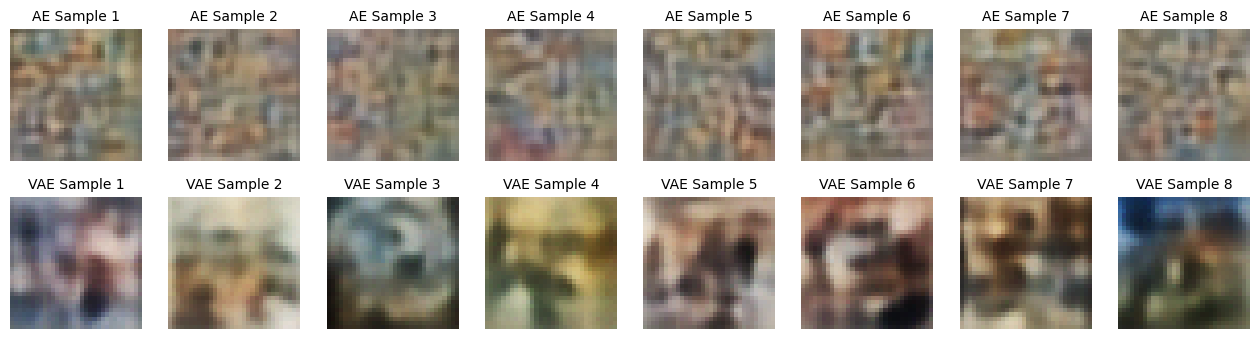

In [47]:
# --- GENERATIVE SAMPLING COMPARISON ---
def compare_generation(ae_model, vae_model, z_dim, n = 8):

    """
    Compares the generative capabilities of AE and VAE by sampling from the latent prior.
    Since only the VAE regularizes the latent space toward a Normal distribution N(0,I),
    this test highlights the difference between a structured and an unstructured latent space.
    """

    ae_model.eval()
    vae_model.eval()

    # Define latent dimensions for both architectures
    z_dim_ae = 256 
    z_dim_vae = 128

    # Random noise for both models
    z_ae = torch.randn(n, z_dim_ae).to(device)
    z_vae = torch.randn(n, z_dim_vae).to(device)

    with torch.no_grad():
        # AE Generation: Direct decoding of random noise.
        gen_ae = ae_model.decode(z_ae).cpu().clamp(0,1)

        # VAE Generation: Direct decoding of random noise.
        gen_vae = vae_model.decode(z_vae).cpu().clamp(0,1)

    # Plotting
    fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
    for i in range(n):
        axes[0, i].imshow(gen_ae[i].permute(1, 2, 0))
        axes[0, i].axis('off')
        axes[0, i].set_title(f"AE Sample {i+1}", fontsize=10)
        
        
        axes[1, i].imshow(gen_vae[i].permute(1, 2, 0))
        axes[1, i].axis('off')
        axes[1, i].set_title(f"VAE Sample {i+1}", fontsize=10)

    plt.show()

best_vae = ConvVAE(latent_dim=128, base_filters=64).to(device)
best_vae.load_state_dict(torch.load('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_0005_f64_e20_b0_1.pth'))
compare_generation(best_model, best_vae, z_dim = 128)

This figure illustrates the fundamental difference between a standard **Autoencoder (AE)** and a **Variational Autoencoder (VAE)** when **generating new content from random noise**
- **AE Samples**: The image generated by AE appear as inconsistent with very little structural or color diversity. This occurs because the AE latent space is **unregularized** and **discontinuous**. When we sample a random vector, the decoder lands in "holes" in latent space that were never populated during training.
- **VAE Samples**: The VAE produces samples with distinct colors and recognizable artistic compositions. Although the images remain somewhat blurry due to the MSE loss, they exhibit **semantic coherence**. This is the result of the **KL Divergence** constraint, which forces the latent space into a continuous Gaussian distribution, ensuring that every point in the space maps to a realistic feature of the ArtBench dataset.

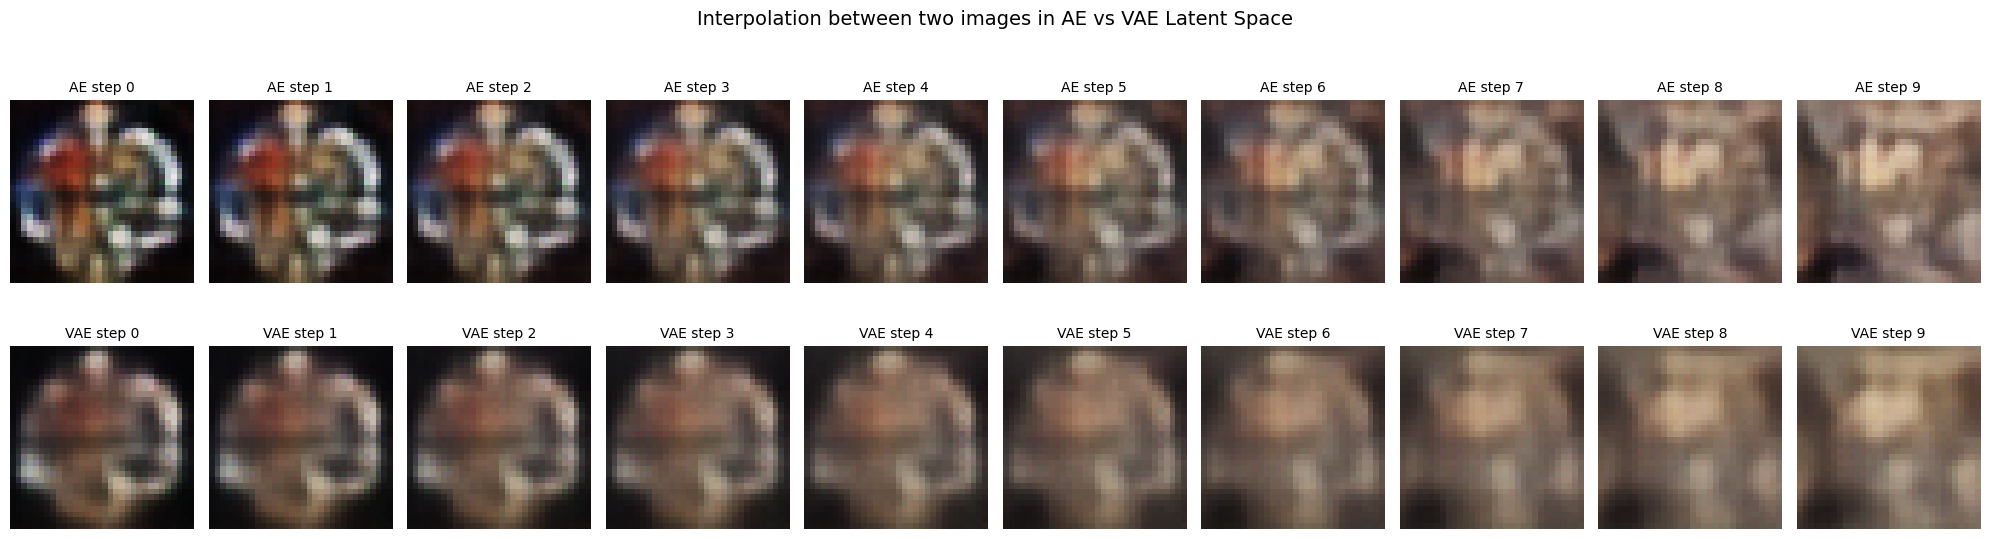

In [48]:
# --- LATENT SPACE INTERPOLATION ANALYSIS ---
def compare_interpolation(ae_model, vae_model, loader, n_steps=10):

    """
    Analyzes the continuity of the latent space by interpolating between 
    two real image embeddings. This test demonstrates whether the model 
    has learned a smooth manifold (VAE) or a discrete mapping (AE).
    """

    ae_model.eval()
    vae_model.eval()

    # Select two real images (Start and End points) from the dataset
    images, _, _ = next(iter(loader))
    start = images[0:1].to(device)  # Source image
    end = images[1:2].to(device)  # Target image 

    # Define linear interpolation coefficients (alphas) from 0.0 to 1.0
    alphas = torch.linspace(0, 1, steps=n_steps).to(device)


    with torch.no_grad():

        # Map pixels to deterministic latent codes
        z_start_ae = ae_model.encode(start)
        z_end_ae = ae_model.encode(end)

        # AE interpolation
        interp_ae = []
        for a in alphas:
            z_interp = (1 - a) * z_start_ae + a * z_end_ae
            interp_ae.append(ae_model.decode(z_interp))
        interp_ae = torch.cat(interp_ae, dim=0).cpu().clamp(0,1)

        # VAE interpolation
        mu_start, _ = vae_model.encode(start)
        mu_end, _ = vae_model.encode(end)

        interp_vae = []
        for a in alphas:
            z_interp = (1 - a) * mu_start + a * mu_end
            interp_vae.append(vae_model.decode(z_interp))
        interp_vae = torch.cat(interp_vae, dim=0).cpu().clamp(0,1)
    
    # Plotting
    fig, axes = plt.subplots(2, n_steps, figsize=(n_steps * 2, 6))
    for i in range(n_steps):
        axes[0, i].imshow(interp_ae[i].permute(1, 2, 0))
        axes[0, i].axis('off')
        axes[0, i].set_title(f"AE step {i}", fontsize=10)
        
        axes[1, i].imshow(interp_vae[i].permute(1, 2, 0))
        axes[1, i].axis('off')
        axes[1, i].set_title(f"VAE step {i}", fontsize=10)
    
    plt.suptitle("Interpolation between two images in AE vs VAE Latent Space", fontsize=14)
    plt.tight_layout()
    plt.show()

compare_interpolation(best_model, best_vae, train_loader_from_csv, n_steps=10)


### Latent Space Interpolation Analysis: AE vs. VAE
The provided image visualizes a comparative study of **latent space continuity** between a standard **Autoencoder (AE)** and a **Variational Autoencoder (VAE)** trained on the ArtBench dataset. By performing a *linear interpolation* between the latent representations of two distinct images, we can evaluate how each model structures its internal understanding of the data.

1. #### Standard Autoencoder
    The interpolation sequence of AE shows **structural instability**. While the model transitions from the first to the last image, the intermediate steps (Steps 3 through 6) show abrupt changes and "ghosting" artifacts. The main reason is for the **unregularized latent space**. Because the AE does not force its latent vectors into a continuous distribution, the space between encoded data points is often "empty." When the decoder is forced to interpret these unknown regions, it produces incoherent or visually fractured results, as seen in the sharp flickering of colors and shapes.

2. #### Variational Autoencoder
    The VAE sequence demonstrates superior **semantic morphing** and **fluid transitions**. The shift from the warm, dark tones of Step 0 to the cooler, blueish hues of Step 9 happens gradually across the manifold. The main reason is for the **KL Divergence** constraint. By forcing the latent space to follow a Gaussian distribution, the VAE ensures **manifold continuity**. Every intermediate point between two images is mathematically "meaningful" to the decoder, allowing it to generate plausible hybrid features (blending light, color, and texture) rather than just overlapping pixels.

----------------------------------------------------------------------------------------------------

## DCGAN (Deep Convolutional GAN)

#### Generator
Transform a vector of noise into an image 32x32 (that seems real), try to fool the Discriminator

In [20]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, image_channels=3, ngf=64):
        # ngf = number of generator filters (base) 
        super().__init__()
        self.latent_dim = latent_dim

        # Input: latent_dim x 1 x 1
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State size: ngf * 4 x 4 x 4
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State size: ngf * 2 x 8 x 8
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State size: ngf x 16 x 16
            nn.ConvTranspose2d(ngf, image_channels, 4, 2, 1, bias=False),
            
            # Convert values in [-1, 1]
            nn.Tanh()
            # Output size: image_channels x 32 x 32
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim, 1, 1)  # reshape to (B, latent_dim, 1, 1)
        return self.model(z)

#### Discriminator

The goal is to see the image and understand if is **true** or **false**


In [21]:
class Discriminator(nn.Module):
    def __init__(self, image_channels=3, ndf=64):
        super().__init__()
        self.model = nn.Sequential(
            # Input: {image_channels} x 32 x 32
            nn.Conv2d(image_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: {ndf} x 16 x 16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: {ndf * 2} x 8 x 8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: {ndf * 4} x 4 x 4
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1,1)

In [22]:
# --- DCGAN WEIGHT INITIALIZATION ---
def init_dcgan_weights(model):
    for m in model.modules():
        # INITIALIZING CONVOLUTIONAL LAYERS
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        
        # INITIALIZING BATCH NORMALIZATION LAYERS
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

### Training Loop

In [23]:
# --- ADVERSARIAL TRAINING PIPELINE (GAN) ---
def train_gan(generator, discriminator, dataloader, latent_dim, opt_g, opt_d, num_epochs=20, lr=2e-4):

    """
    Executes the adversarial training loop.
    The goal is to reach a Nash Equilibrium where the Discriminator cannot 
    distinguish between real ArtBench-10 samples and synthetic images.
    """

    # Binary Cross Entropy Loss is the standard objective for GANs
    criterion = nn.BCELoss()

    history = {
        'gen_loss': [],
        'disc_loss': []
    }

    generator.train()
    discriminator.train()

    for epoch in range(num_epochs):
        gen_loss = 0.0
        disc_loss = 0.0
        n_batches = 0
        for real_imgs, _, _ in dataloader:
            real_img = real_imgs.to(device)
            batch_size = real_img.size(0)

            # Ground truth labels for the discriminator
            real_targets = torch.ones(batch_size, 1).to(device)
            fake_targets = torch.zeros(batch_size, 1).to(device)

            # --- PHASE 1: TRAIN DISCRIMINATOR ---
            opt_d.zero_grad()

            # Forward pass with real dataset images
            real_output = discriminator(real_img)
            d_loss_real = criterion(real_output, real_targets)

            # Forward pass with synthetic images
            z = torch.randn(batch_size, latent_dim).to(device)
            fake_img = generator(z)
            fake_output = discriminator(fake_img.detach())
            d_loss_fake = criterion(fake_output, fake_targets)

            # Total Discriminator loss: Sum of Real and Fake classification errors
            d_loss = d_loss_real + d_loss_fake

            d_loss.backward()
            opt_d.step()

            # --- PHASE 2: TRAIN GENERATOR ---
            opt_g.zero_grad()

            # Generate new fake images and pass them through the updated Discriminator
            z = torch.randn(batch_size, latent_dim).to(device)
            fake_img = generator(z)
            output = discriminator(fake_img)
            g_loss = criterion(output, real_targets)  # Generator wants discriminator to predict real

            g_loss.backward()
            opt_g.step()

            gen_loss += g_loss.item()
            disc_loss += d_loss.item()
            n_batches += 1
        
        history['gen_loss'].append(gen_loss / n_batches)
        history['disc_loss'].append(disc_loss / n_batches)

        print(f"Epoch {epoch+1}/{num_epochs} - Gen Loss: {history['gen_loss'][-1]:.4f}, Disc Loss: {history['disc_loss'][-1]:.4f}")
    
    return history

In [24]:
import itertools

# --- DCGAN HYPERPARAMETER SEARCH SPACE ---
gan_search_space = {
    'z': [100, 128],                                                # Latent vector dimensionality
    'lr': [(2e-4, 2e-4), (1e-4, 4e-4)],                             # Learning rates: (Generator, Discriminator)       
    'epochs': [20, 30],                                             # Fixed training iterations for the grid search
    'filters': [(64, 64), (128, 64), (32, 64)]                      # Feature map depth: (NGF, NDF)
}

keys = gan_search_space.keys()
values = gan_search_space.values()
combinations = list(itertools.product(*values))

gan_configs = []
for combo in combinations:
    config = dict(zip(keys, combo))
    ngf, ndf = config['filters']
    lrg, lrd = config['lr']
    config['name'] = f"DCGAN_z{config['z']}_lrG{config['lr'][0]}_lrD{config['lr'][1]}_ngfG{config['filters'][0]}_ngfD{config['filters'][1]}_e{config['epochs']}"
    gan_configs.append(config)

print(f"Ready to test {len(gan_configs)} GAN configurations:")
for cfg in gan_configs:
    print(f" - {cfg['name']}")

Ready to test 24 GAN configurations:
 - DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20
 - DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20
 - DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20
 - DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e30
 - DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e30
 - DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e30
 - DCGAN_z100_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e20
 - DCGAN_z100_lrG0.0001_lrD0.0004_ngfG128_ngfD64_e20
 - DCGAN_z100_lrG0.0001_lrD0.0004_ngfG32_ngfD64_e20
 - DCGAN_z100_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e30
 - DCGAN_z100_lrG0.0001_lrD0.0004_ngfG128_ngfD64_e30
 - DCGAN_z100_lrG0.0001_lrD0.0004_ngfG32_ngfD64_e30
 - DCGAN_z128_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20
 - DCGAN_z128_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20
 - DCGAN_z128_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20
 - DCGAN_z128_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e30
 - DCGAN_z128_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e30
 - DCGAN_z128_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e30
 - DCGAN_z128_lrG0.00

In [45]:
# --- DCGAN GRID SEARCH EXECUTION PIPELINE ---

# Initialize the GAN-specific data loader using [-1, 1] normalization
train_loader_gan, _ = build_artbench_loaders(
    train_hf,
    test_hf,
    train_ids=train_ids_from_csv,
    use_gan_norm=True
)


all_gan_results = {}
N_SAMPLES = 2000 # Sample size for statistical evaluation (FID/KID)

for idx, cfg in enumerate(gan_configs):
    print(f"\nCONFIG {idx+1}/{len(gan_configs)}: {cfg['name']}")

    # Check if model already exists
    ckpt_path = Path(f"/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/{cfg['name']}.pth")

    ngf, ndf = cfg['filters']
    lrg, lrd = cfg['lr']
    latent_dim = cfg['z']

    # Initialize Generator and Discriminator with config-specific feature map depths
    netG = Generator(latent_dim=latent_dim, ngf=ngf).to(device)
    netD = Discriminator(ndf=ndf).to(device)

    # UPDATE or TRAINING
    if ckpt_path.exists():
        print(f"Model checkpoint found for {cfg['name']}. Loading model...")
        checkpoint = torch.load(ckpt_path)
        netG.load_state_dict(checkpoint['generator'])
        netD.load_state_dict(checkpoint['discriminator'])
        history = checkpoint['history']
    else:
        print(f"No checkpoint found for {cfg['name']}. Starting training...")
        
        # Apply standard DCGAN weight initialization
        init_dcgan_weights(netG)
        init_dcgan_weights(netD)

        # OPTIMIZER CONFIGURATION
        opt_g = torch.optim.Adam(netG.parameters(), lr=lrg, betas=(0.5, 0.999))
        opt_d = torch.optim.Adam(netD.parameters(), lr=lrd, betas=(0.5, 0.999))

        # Training
        history = train_gan(
            generator=netG, 
            discriminator=netD, 
            dataloader=train_loader_gan, 
            latent_dim=cfg['z'], 
            num_epochs=cfg['epochs'],
            opt_g=opt_g,
            opt_d=opt_d
        )

        # Save model after training
        save_gan_model(netG, netD, history, cfg, ckpt_dir="/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models")
        
    
    
    # Clean
    del netG, netD
    torch.cuda.empty_cache()

Preprocessing: using GAN/Diffusion normalization ([-1,1])
Notebook kernel detected: forcing num_workers=0 for DataLoader stability.

CONFIG 1/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20
Model checkpoint found for DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20. Loading model...

CONFIG 2/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20
Model checkpoint found for DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20. Loading model...

CONFIG 3/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20
Model checkpoint found for DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20. Loading model...

CONFIG 4/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e30
Model checkpoint found for DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e30. Loading model...

CONFIG 5/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e30
Model checkpoint found for DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e30. Loading model...

CONFIG 6/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e30
Model checkpoint

In [46]:
import pandas as pd

# --- QUANTITATIVE EVALUATION: GAN FID/KID BENCHMARKING ---

# Collect real images using GAN normalization [-1, 1].
# For metric consistency, images are mapped back to [0, 1] via denorm() 
# before conversion to uint8 format.
real_images_gan_norm = collect_real_images_from_loader(train_loader_gan, max_images=N_SAMPLES)
real_images_gan_norm = denorm(real_images_gan_norm)
real_uint8 = to_uint8_artbench10(real_images_gan_norm.cpu())

all_gan_results = {}
best_fid = float('inf')
best_cfg_name = ""
idx = 0

GAN_RESULTS_FILE = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/Results/GAN_results.json")

# 1. Caricamento risultati esistenti (se il file esiste già)
if GAN_RESULTS_FILE.exists():
    with open(GAN_RESULTS_FILE, "r") as f:
        all_gan_results = json.load(f)
    print(f"Recovered {len(all_gan_results)} previous results from JSON file.")

print(f"\nEvaluation of {len(gan_configs)} GANs configurations...")

for cfg in gan_configs:
    idx = idx + 1
    print(f"\n CONFIGURATION {idx}/{len(gan_configs)}: {cfg['name']}")

    ckpt_path = Path(f"/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/{cfg['name']}.pth")
    
    if not ckpt_path.exists():
        continue

    # 2. Upload Model
    checkpoint = torch.load(ckpt_path, map_location=device)
    netG = Generator(latent_dim=cfg['z'], ngf=cfg['filters'][0]).to(device)
    netG.load_state_dict(checkpoint['generator'])
    netG.eval()

    # DCGAN architecture requires a 4D noise tensor (Batch, Z, 1, 1).
    # Generated samples are denormalized to [0, 1] for standardized evaluation.
    with torch.no_grad():
        noise = torch.randn(N_SAMPLES, cfg['z'], 1, 1, device=device)
        gen_images = netG(noise)
        gen_images = denorm(gen_images)
    
    gen_uint8 = to_uint8_artbench10(gen_images.cpu())

    # METRIC COMPUTATION
    fid_val, kid_val = compute_fid(real_uint8, gen_uint8)

    # Persist metrics to central JSON log
    update_results_json(GAN_RESULTS_FILE, cfg['name'], fid_val, kid_val)
    
    all_gan_results[cfg['name']] = {
        'fid': fid_val,
        'kid': kid_val
    }

    # Tracking the "Champion" configuration
    if fid_val < best_fid:
        best_fid = fid_val
        best_cfg_name = cfg['name']
        best_config = cfg

    del netG
    torch.cuda.empty_cache()

# --- FINAL TABULAR PERFORMANCE SUMMARY ---
print("\n" + "="*70)
print(f"{'GAN CONFIGURATION':<50} | {'FID (↓)':<10} | {'KID (↓)':<10}")
print("-" * 70)
for name, res in all_gan_results.items():
    print(f"{name:<50} | {res['fid']:>10.2f} | {res['kid']:>10.4f}")
print("="*70)

print(f"\nBEST MODEL: {best_cfg_name}")
print(f"BEST FID SCORE: {best_fid:.2f}")

best_ckpt = Path(f"/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/{best_cfg_name}.pth")
best_data = torch.load(best_ckpt, map_location=device)


save_model(
    model_type_name="best_GAN",
    weights=best_data,
    history=best_data['history'],
    config=best_config,
    overwrite=True
)

Recovered 24 previous results from JSON file.

Evaluation of 24 GANs configurations...

 CONFIGURATION 1/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Results for 'DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20' saved in: GAN_results.json

 CONFIGURATION 2/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20
Results for 'DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20' saved in: GAN_results.json

 CONFIGURATION 3/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20
Results for 'DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20' saved in: GAN_results.json

 CONFIGURATION 4/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e30
Results for 'DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e30' saved in: GAN_results.json

 CONFIGURATION 5/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e30
Results for 'DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e30' saved in: GAN_results.json

 CONFIGURATION 6/24: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e30
Results for 'DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e30' saved in: GAN_results.json

 CONFIGURATION 7/24: DCGAN_z100_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e20
Results for 'DCGAN_z100_lrG0.0

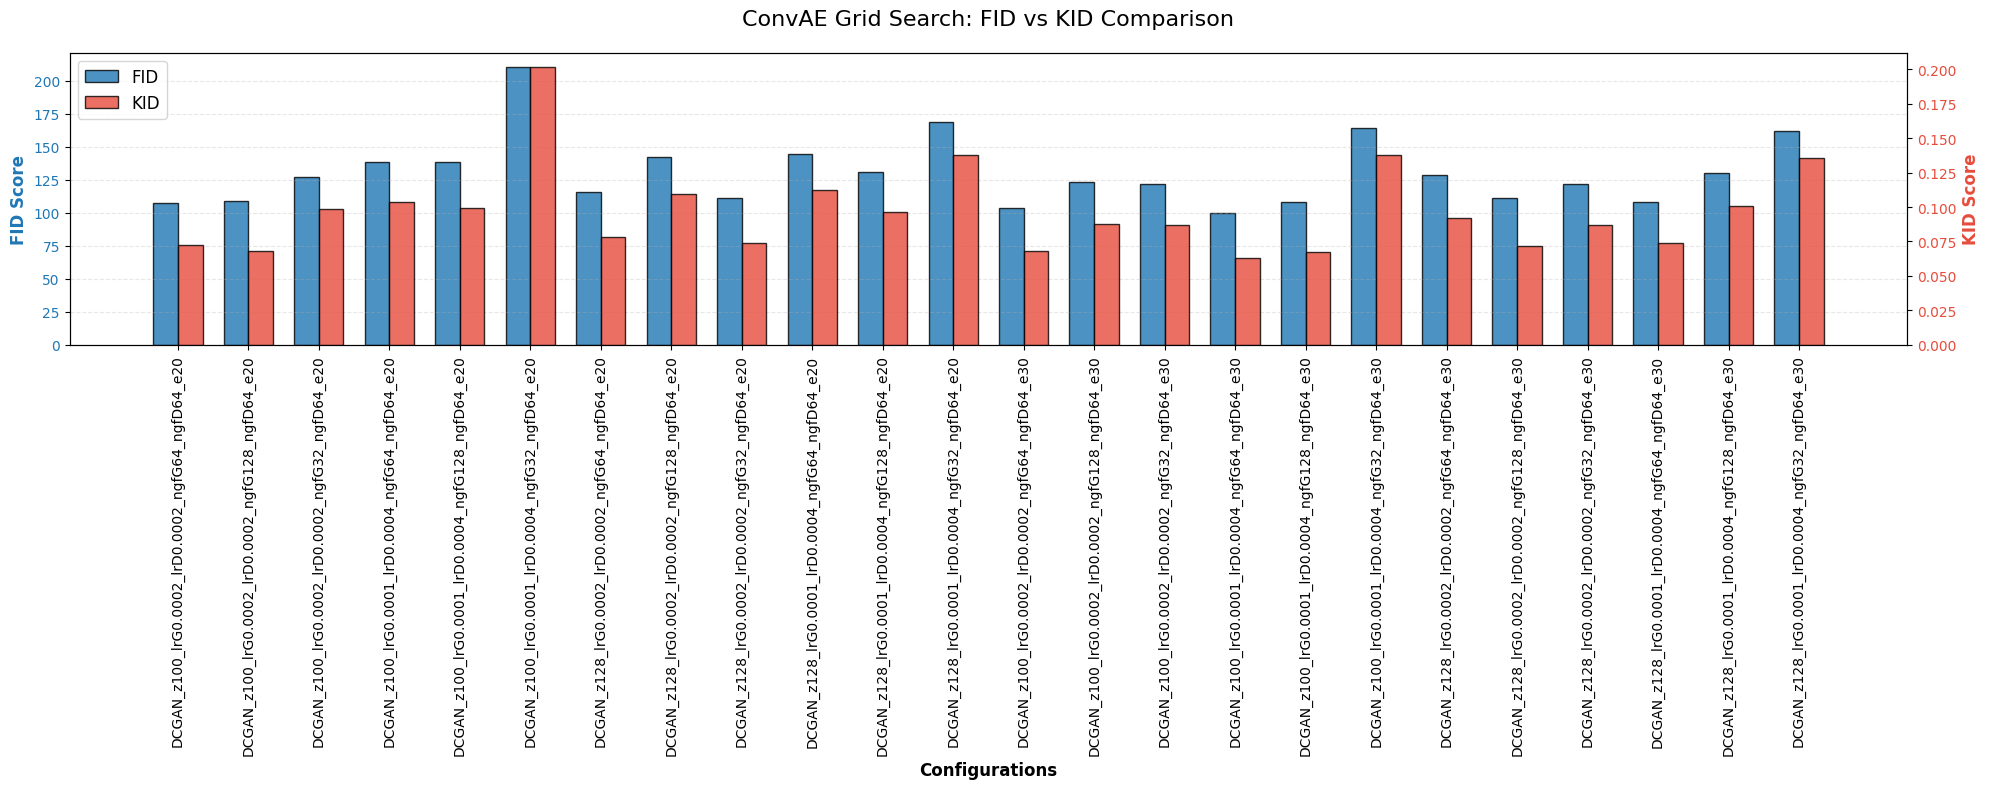

In [56]:
plot_fid_kid_comparison(all_gan_results)

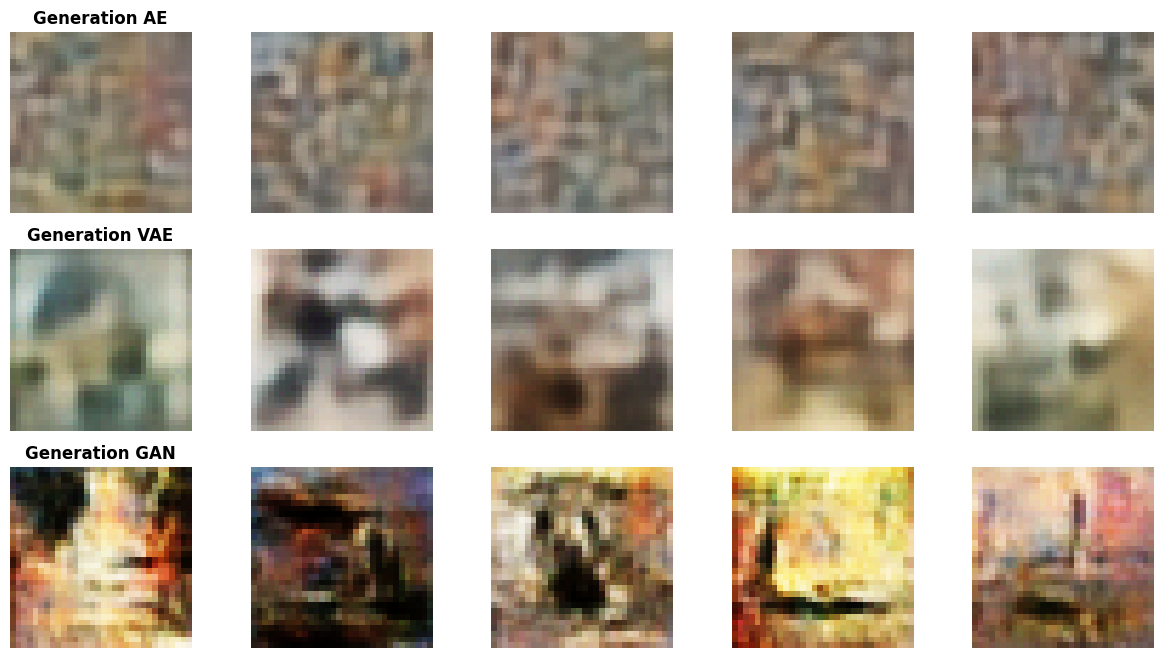

In [60]:
import torch
import matplotlib.pyplot as plt

# --- MULTI-MODEL GENERATIVE BENCHMARK ---

# LATENT SPACE DIMENSIONALITY SETUP
z_ae = best_model.decoder_input.in_features
z_vae = best_vae.decoder_input.in_features

# Loading the optimal GAN configuration
checkpoint_gan = torch.load("/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/best_GAN.pth")

# Recover GAN hyperparameters (Z dimension and feature map depth) from the saved config
cfg_gan = checkpoint_gan['config']
z_gan = cfg_gan['z']
ngf_gan = cfg_gan['filters'][0] 

# Initialize the Generator architecture and map the saved weights
best_gan_generator = Generator(latent_dim=z_gan, ngf=ngf_gan).to(device)
best_gan_generator.load_state_dict(checkpoint_gan['generator'])
best_gan_generator.eval()


n_images = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# PRIOR SAMPLING (LATENT NOISE)
noise_simple_ae = torch.randn(n_images, z_ae).to(device) 
noise_simple_vae = torch.randn(n_images, z_vae).to(device) 
noise_gan = torch.randn(n_images, z_gan, 1, 1).to(device)

# # 3. GENERATIVE INFERENCE
with torch.no_grad():
    # AE PATH: Mapping latent noise through the linear bottleneck to the decoder
    feat_ae = best_model.decoder_input(noise_simple_ae).view(-1, 256, 4, 4)
    out_ae = best_model.decoder(feat_ae)
    
    # VAE PATH: Sampling directly from the learned Gaussian manifold
    out_vae = best_vae.decode(noise_simple_vae)
    
    # GAN PATH: Transforming noise into pixel space via transposed convolutions
    # Output is rescaled from Tanh range [-1, 1] back to standard [0, 1]
    out_gan = best_gan_generator(noise_gan)
    out_gan = denorm(out_gan)

# VISUALIZATION AND ARCHITECTURAL COMPARISON
fig, axes = plt.subplots(3, n_images, figsize=(15, 8))
names = ["Generation AE", "Generation VAE", "Generation GAN"]
output_models = [out_ae, out_vae, out_gan]

for rows in range(3):
    for cols in range(n_images):
        
        # Move tensors to CPU and permute channels (C, H, W -> H, W, C) for Matplotlib
        img = output_models[rows][cols].cpu().permute(1, 2, 0).numpy()
        axes[rows, cols].imshow(img.clip(0, 1))
        axes[rows, cols].axis('off')
        if cols == 0:
            axes[rows, cols].set_title(names[rows], loc = 'center', fontweight='bold')

plt.show()

----------------------------------------------------------------------------------------------------------------------------------------------------

## Diffusion Models

#### Schedule and Forward Diffusion Helpers


In [21]:
class GaussianDiffusion:
    def __init__(self, num_timesteps=1000, beta_start=1e-4, beta_end=0.02, schedule='linear', device='cpu'):
        self.num_timesteps = num_timesteps
        self.device = device

        # Linear beta scheduler
        # start few noise
        # end lot of noise

        if schedule == 'linear':
            # beta : how many noise we add at each step
            self.betas = torch.linspace(beta_start, beta_end, num_timesteps).to(device)
        elif schedule == 'cosine':
            self.betas = self.cosine_beta_schedule(num_timesteps).to(device)

        # alphas : how much of the original image we keep at each step
        self.alphas = 1. - self.betas

        # cumulative product of alphas (how much of the original image we keep after t steps)
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

        # for have [1.0, alpha_bar_0, alpha_bar_1, ..., alpha_bar_{T-1}]
        self.alphas_cumprod_prev = torch.cat([
            torch.tensor([1.]).to(device), # Add 1 at the beginning for t=0
            self.alphas_cumprod[:-1] # Take all but the last element for t=1 to T

        ])

        # FORWARD DIFFUSION -> Transform image into noise
        # we need to compute:
        # - sqrt(alpha_cumprod) for scaling the original image
        # - sqrt(1 - alpha_cumprod) for scaling the noise
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)

        # REVERSE DIFFUSION -> Transform noise into image $q(x_{t-1} | x_t, x_0)$
        # Distribution of x_{t-1} given x_t and x_0 is a Gaussian with mean and variance:

        # - POSTERIOR MEAN
        #   - posterior_mean_coef1 = is the weight given for x_0 in the calculation of the mean. 
        #                             More near to the start, more highter is the weight for x_0, because we have less noise
        #   - posterior_mean_coef2 = is the weight given for x_t in the calculation of the mean.
        #                             More near to the end, more highter is the weight for x_t, because we have more noise
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        self.posterior_mean_coef2 = (1. - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1. - self.alphas_cumprod)

        # - POSTERIOR VARIANCE
        #   - posterior_variance = is the variance of the distribution of x_{t-1} given x_t and x_0. 
        #                          More near to the end, more highter is the variance, because we have more noise
        self.posterior_variance = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)

        """
        Take clear image and insert noise at step t
        """
    def q_sample(self, x_0, t, noise=None):
        # x_0: original image
        # t: timestep
        # noise: if we want to specify the noise, otherwise it will be sampled from a normal distribution
        if noise is None:
            noise = torch.randn_like(x_0)
            
        # take the coefficients for the given timestep t
        sqrt_alpha_prod = self._get_index(self.sqrt_alphas_cumprod, t, x_0.shape)
        sqrt_one_minus_alpha_prod = self._get_index(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)

        return sqrt_alpha_prod * x_0 + sqrt_one_minus_alpha_prod * noise

    """
    Remove some noise from the image at step t, given the predicted noise
    """
    @torch.no_grad()
    def p_sample(self, model, x, t, t_index):
        # model: the noise predictor model
        # x: the noisy image at step t
        # t: the current timestep
        # t_index: the index of the current timestep (0 to num_timesteps-1)

        # recover the coefficients for the current timestep
        betas_t = self._get_index(self.betas, t, x.shape)
        sqrt_one_minus_alpha_cumprod_t = self._get_index(self.sqrt_one_minus_alphas_cumprod, t, x.shape)
        sqrt_recip_alphas_t = 1. / torch.sqrt(self._get_index(self.alphas, t, x.shape))

        # predict the noise using the model
        predicted_noise = model(x, t)

        model_mean = sqrt_recip_alphas_t * (x - betas_t * predicted_noise / sqrt_one_minus_alpha_cumprod_t)

        if t_index == 0:
            return model_mean
        else:
            # Add some noise for the stochasticity of the reverse process
            posterior_variance_t = self._get_index(self.posterior_variance, t, x.shape)
            noise = torch.randn_like(x)
            return model_mean + torch.sqrt(posterior_variance_t) * noise
        
    """
    Function that generate the images
    INPUT:
    - model == network who predicts the noise
    - shape == shape of the batch (batch_size, 3, 32, 32) --> RGB images
    """
    @torch.no_grad()
    def p_sample_loop(self, model, shape):
        # Sample all steps from pure noise to reconstruct an image in latent space
        model.eval()

        # start with noise x_T
        x = torch.randn(shape).to(self.device)

        # reverse from T-1 back to 0
        for i in reversed(range(0, self.num_timesteps)):

            # make a vector (tensor) of size = batch_size (shape[0])
            # where each element has the actual step value i
            t = torch.full((shape[0], ), i, dtype=torch.long).to(self.device)

            # denoising pass
            x = self.p_sample(model, x, t, i)
            
        return x

    def _get_index(self, tensor, t, x_shape):
        # x_shape = (64, 3, 32, 32)
        # tensor = vector with all the noises --> shape (num_timesteps, )
        # t = index t of the timesteps for all the images

        # EXAMPLE t = [10, 44, 100, 200, ....] ---> out = [beta_10, beta_44, beta_100, beta_200, ....] until 64 noises
        out = tensor.gather(-1, t)

        # BROADCASTING
        # from (64, 3, 32, 32) --> (64, 1, 1, 1)
        return out.view(t.shape[0], 1, 1, 1)
    
    def cosine_beta_schedule(self, timesteps, s=0.008):
        """
        Cosine schedule as proposed in 'Improved Denoising Diffusion Probabilistic Models'.
        Provides a smoother noise transition than linear schedule.
        """
        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)





### Denoiser Network

In [22]:
import math
# Transformation of the timestep t (scalar) into a vector with a lot of informations
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # Final dimension of the embedding vector
        self.dim = dim
    
    def forward(self, x):
        # x represent the timestep t
        
        device = x.device

        # To create a balanced embedding of sin and cos, we work with half of dimension
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)

        # Generate a sequence of exp decaying frequencies
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)

        # Multiply the timestep t by each frequency generated
        emb = x[:, None] * emb[None, :]

        # Apply sin and cos to the phases and concatenate them
        # The final vector is [sin(f1*t), ..., sin(fn*t), cos(f1*t), ..., cos(fn*t)]
        # This allows the model to capture both high-frequency (fast changes) 
        # and low-frequency (slow changes) patterns in time.
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)

        return emb
    
class ResnetBlock(nn.Module):

    """
    Core building block of the Diffusion model: a ResNet block conditioned on time.
    It combines image features with temporal information to modulate noise prediction.
    """
    
    def __init__(self, dim, time_emb_dim, out_dim=None):
        super().__init__()
        # If out_dim is not specified, keep the same number of channels
        self.out_dim = out_dim or dim

        # TIME EMBEDDING PROJECTION:
        # Projects the global time embedding into local feature dimension
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, self.out_dim)
        )

        # CONVOLUTIONAL LAYERS
        # conv1 = initial feature extraction and channel transformation (if dimensions are different)
        self.conv1 = nn.Conv2d(dim, self.out_dim, 3, padding=1)
        # conv2 = Refines features after time information has been injected
        self.conv2 = nn.Conv2d(self.out_dim, self.out_dim, 3, padding=1)

        # NORMALIZATION LAYERS
        self.norm1 = nn.GroupNorm(4, dim)
        self.norm2 = nn.GroupNorm(4, self.out_dim)
        self.act = nn.SiLU()

        # Shortcut Connection (Residual):
        # If input and output dimensions differ, use a 1x1 conv to match them
        self.shortcut = nn.Conv2d(dim, self.out_dim, 1) if dim != self.out_dim else nn.Identity()

    def forward(self, x, time_emb):
        
        """
        x: Input feature map [Batch, Channels, Height, Width]
        time_emb: Global time embedding [Batch, time_emb_dim]
        """
        # First step: Feature Extraction
        h = self.norm1(x)
        h = self.act(h)

        h = self.conv1(h) # Example [B, 32, 32, 32] -> [B, 64, 32, 32]

        # Second step: Time Injection
        # Project the time emb to match the image channels
        time_emb = self.mlp(time_emb)
        # Reshape [B, C] -> [B, C, 1, 1] for broadcasting

        # Add time info to every pixel: every cell now knows the current noise
        h = h + time_emb[:, :, None, None]

        # Third Step: Refinement
        h = self.norm2(h)
        h = self.act(h)
        h = self.conv2(h)

        # Combined processed features with the original input (Residual connection)
        return self.shortcut(x) + h


"""
Predicts the noise inside the Latent Space
"""
class LatentDenoiseNetwork(nn.Module):
    """
    Denoising network operating on latent tensors of shape [B, latent_channels, H_lat, W_lat]
    """
    # Assume that AE compress images from (64, 3, 32, 32) into (64, 4, 8, 8)

    def __init__(self, latent_channels=4, model_channels=64, num_res_blocks=3):
        super().__init__()

        # Transforms the step number t into a vector with some useful informations
        # TIME EMBEDDING

        self.time_emb = nn.Sequential(
            # INPUT = vector t of shape (B, ) -> batch_size scalar numbers
            # SinusoidalPosEmb transforms each scalar into a vector of dimension model_channels = 64
            # Now I have 64 vectors of dimension 64
            SinusoidalPosEmb(model_channels),
            nn.Linear(model_channels, model_channels * 4),
            nn.SiLU(),
            # now [64, 64] --> [64, 256]
            nn.Linear(model_channels * 4, model_channels * 4),
        )

        # OUTPUT = time_emb = [B, 256]

        # Start into latent space
        # [B, 4, H, W] -> [B, 64, H, W]
        self.init_conv = nn.Conv2d(latent_channels, model_channels, 3, padding=1)

        """
        RESIDUAL BLOCKS
        Create a list of the type [Block1, Block2, Block3]
        Each block takes:
            x -> [B, 64, H, W]
            time_emb -> [B, 256]
        """
        self.res_blocks = nn.ModuleList([
            ResnetBlock(model_channels, model_channels * 4)
            for _ in range(num_res_blocks)
        ])

        #End latent space
        # [B, 64, H, W] -> [B, 4, H, W]
        self.out_conv = nn.Conv2d(model_channels, latent_channels, 3, padding=1)
    

    def forward(self, x, t):
        """
            INPUT
                x -> [B, 4, H, W]
                t -> [B]
        """

        # Convert [B] into [B, 256]
        t_emb = self.time_emb(t)

        # Convert [64, 4, 8, 8] into [64, 64, 8, 8]
        h = self.init_conv(x)
        for block in self.res_blocks:
            h = block(h, t_emb)
        
        # Return [64, 4, 8, 8]
        return self.out_conv(h)


class PixelUNet(nn.Module):

    def __init__(self, in_channels=3, model_channels=64):
        super().__init__()

        # Time embedding
        self.time_emb = nn.Sequential(
            SinusoidalPosEmb(model_channels),
            nn.Linear(model_channels, model_channels * 4),
            nn.SiLU(),
            nn.Linear(model_channels * 4, model_channels * 4),
        )

        # [B] -> [B, 256]

        # time_dim = 256
        time_dim = model_channels * 4

        # Initial Conv
        # Transformation from [64, 3, 32, 32] --> [64, 64, 32, 32]
        self.init_conv = nn.Conv2d(in_channels, model_channels, 3, padding=1)

        # DOWNSAMPLING
        # 1) Decrease the spatial dimension
        # 2) Increase the number of channels

        # From 32 to 16
        self.down1_res = ResnetBlock(model_channels, time_dim)

        # [64, 64, 32, 32] --> [64, 64, 16, 16]
        self.down1_pool = nn.Conv2d(model_channels, model_channels, 3, stride=2, padding=1)

        # From 16 to 8

        # [64, 64, 16, 16] -> [64, 128, 16, 16]
        self.down2_res = ResnetBlock(model_channels, time_dim, out_dim=model_channels * 2)

        # [64, 128, 16, 16] -> [64, 128, 8, 8]
        self.down2_pool = nn.Conv2d(model_channels * 2, model_channels * 2, 3, stride=2, padding=1)

        # Middle
        self.mid_res1 = ResnetBlock(model_channels * 2, time_dim)
        self.mid_res2 = ResnetBlock(model_channels * 2, time_dim)


        # UPSAMPLING
        # Use the skip connections for spatial details
        
        # 8 -> 16
        # From [64, 128, 8, 8] -> [64, 64, 16, 16]
        self.up2_conv = nn.ConvTranspose2d(model_channels * 2, model_channels, 4, stride=2, padding=1)
        # Skip connection from down2_res is model_channels * 2
        # After concat: model_channels (up) + model_channels * 2 (skip) = model_channels * 3
        self.up2_res = ResnetBlock(model_channels * 3, time_dim, out_dim=model_channels)

        # 16 -> 32
        self.up1_conv = nn.ConvTranspose2d(model_channels, model_channels, 4, stride=2, padding=1)
        # Skip connection from down1_res is model_channel
        # After concat: model_channels (up) + model_channels (skip) = model_channels * 2
        self.up1_res = ResnetBlock(model_channels * 2, time_dim, out_dim=model_channels)

        self.out_conv = nn.Conv2d(model_channels, in_channels, 3, padding=1)

    def forward(self, x, t):

        t_emb = self.time_emb(t)

        # [B, 3, 32, 32]
        h_init = self.init_conv(x)

        # Down1
        h1 = self.down1_res(h_init, t_emb) # [B, 64, 32, 32]
        h1_pool = self.down1_pool(h1) # [B, 64, 16, 16]

        # Down2
        h2 = self.down2_res(h1_pool, t_emb) # [B, 128, 16, 16]
        h2_pool = self.down2_pool(h2) # [B, 128, 8, 8]

        # Middle (BOTTLENECK)
        h_mid = self.mid_res1(h2_pool, t_emb) # [B, 128, 8, 8]
        h_mid = self.mid_res2(h_mid, t_emb) # [B, 128, 8, 8]

        # Up2
        h_up2 = self.up2_conv(h_mid) # [B, 64, 16, 16]
        h_up2 = torch.cat([h_up2, h2], dim=1) # SKIP CONNECTION -> [B, 192, 16, 26]
        h_up2 = self.up2_res(h_up2, t_emb) # [B, 64, 16, 16]

        # Up1
        h_up1 = self.up1_conv(h_up2) # [B, 64, 32, 32]
        h_up1 = torch.cat([h_up1, h1], dim=1) # SKIP CONNECTION -> [B, 128, 32, 32]
        h_up1 = self.up1_res(h_up1, t_emb) # [B, 64, 32, 32]

        return self.out_conv(h_up1)
        


In [23]:
class Encoder(nn.Module):
    def __init__(self, latent_channels=4):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        # Latent space
        self.mu = nn.Conv2d(64, latent_channels, kernel_size=1)
        self.logvar = nn.Conv2d(64, latent_channels,  kernel_size=1)

    def forward(self, x):
        h = self.model(x)
        return self.mu(h), self.logvar(h)
    
class Decoder(nn.Module):
    def __init__(self, latent_channels=4):
        super().__init__()
        self.initial_conv = nn.Conv2d(latent_channels, 64, kernel_size=1)

        self.model = nn.Sequential(
            nn.ConvTranspose2d(64, 64,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        h = self.initial_conv(z)
        return self.model(h)
    
class VAE(nn.Module):
    def __init__(self, latent_channels=4):
        super().__init__()
        self.encoder = Encoder(latent_channels)
        self.decoder = Decoder(latent_channels)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

### Reverse Sampling

In [24]:
@torch.no_grad()
def sample_diffusion(model, schedule, shape):

    model.eval()

    x = torch.randn(shape, device=device)

    # DENOISING LOOP
    for step in reversed(range(schedule['T'])):

        # current step for each image in the batch
        t = torch.full((shape[0], ), step, device=device, dtype=torch.long)

        predict_noise = model(x, t)

        # Parameters from scheduler
        alpha_t = schedule['alphas'][step]
        alpha_bar_t = schedule['alpha_bars'][step]
        beta_t = schedule['betas'][step]

        sqrt_alpha_t = torch.sqrt(alpha_t)
        sqrt_one_minus_alpha_bar_t = torch.sqrt(1. - alpha_bar_t)

        # Add final noise (if we are not in the final step)
        if step > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)
        
        # UPDATE EQUATION
        x = (
            (1. / sqrt_alpha_t) 
            * (x - ((1. - alpha_t) / sqrt_one_minus_alpha_bar_t) * predict_noise)
            + torch.sqrt(beta_t) * noise
            )
    
    return x

## Training Loops

#### Train VAE

In [25]:
# --- AUTOENCODER TRAINING PIPELINE ---

def train_autoencoder(model, loader, epochs=20, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    model.train()

    for epoch in range(epochs):
        running = 0.0
        n_batches = 0
        
        for x, _, _ in (loader):
            x = x.to(device)
            x_hat, _, _ = model(x)

            # We combine Mean Squared Error (MSE) for global luminance/color consistency
            # with L1 (Mean Absolute Error) to encourage sharper edges and sparsity.
            loss = 0.5 * F.mse_loss(x_hat, x) + 0.5 * F.l1_loss(x_hat, x)

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += loss.item()
            n_batches += 1
        
        avg = running / n_batches
        history.append(avg)
        print(f"AE epoch {epoch + 1: 02d}/{epochs} | recon loss: {avg:.4f}")
    
    return history

#### Train Diffusion


In [26]:
# Teach the U-Net to recognize noise
# --- DIFFUSION TRAINING PIPELINE (NOISE ESTIMATION) ---
def train_diffusion(model, loader, schedule, epochs=5, lr=4e-4, encode_fn=None):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    model.train()

    for epoch in range(epochs):
        running = 0.0
        n_batches = 0

        for x, _, _ in (loader):
            x = x.to(device)

            # --- LATENT SPACE TRANSFORMATION ---
            # If an encode_fn is provided (LDM), the image is projected into 
            # the VAE latent space before the diffusion process begins.
            if encode_fn is not None:
                with torch.no_grad():
                    x, _ = encode_fn(x)
            
            batch_size = x.shape[0]

            # TIMESTEP SAMPLING
            t = torch.randint(0, schedule.num_timesteps, (batch_size, ), device=device).long()

            # NOISE INJECTION (FORWARD PROCESS)
            target_noise = torch.randn_like(x)

            # Use the diffusion schedule to produce the noisy version of x at time t (x_t)
            x_t = schedule.q_sample(x, t, noise=target_noise)

            # NOISE PREDICTION (BACKWARD PROCESS)
            # The U-Net attempts to predict the 'target_noise' from the 'x_t' input,
            # conditioned on the specific timestep 't'.
            predicted_noise = model(x_t, t.long())

            # OBJECTIVE FUNCTION
            loss = F.mse_loss(predicted_noise, target_noise)

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += loss.item()
            n_batches += 1
        
        avg = running / n_batches
        history.append(avg)
        print(f"Diffusion epoch {epoch + 1:02d}/{epochs} | MSE Loss: {avg:.4f}")
    
    return history
            



In [27]:
train_loader_diffusion, test_loader_diffusion = build_artbench_loaders(
    train_hf,
    test_hf,
    train_ids=train_ids_from_csv,
    use_gan_norm=True
)

timesteps = 300
pixel_diffusion = GaussianDiffusion(num_timesteps=timesteps, device=device)
pixel_model = PixelUNet(in_channels=3, model_channels=64).to(device)

pixel_history = fit_or_load_model(
    model=pixel_model,
    name="PixelDiffusion",
    train_function=train_diffusion,
    loader=train_loader_diffusion,
    schedule=pixel_diffusion,
    epochs=20,
    lr=2e-4,
    encode_fn=None,
    load_if_available=True
)


Preprocessing: using GAN/Diffusion normalization ([-1,1])
Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Upload model "PixelDiffusion" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/pixeldiffusion.pth


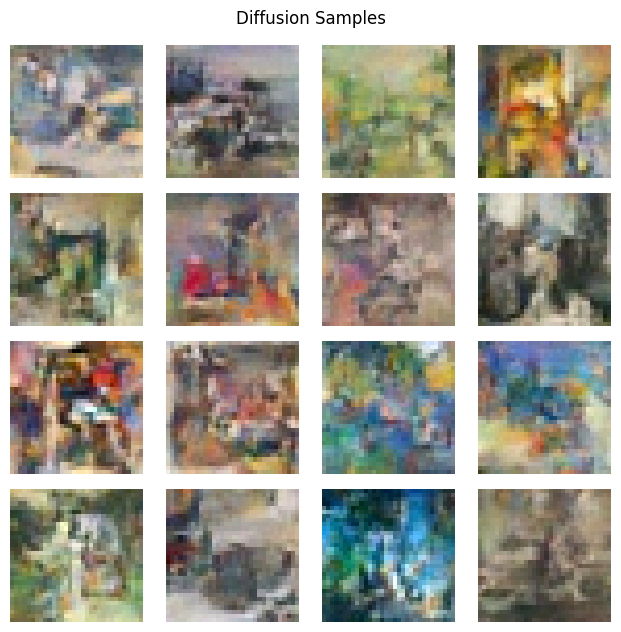

In [28]:
import torchvision.utils as vutils
sample_shape = (16, 3, 32, 32)

sampled = pixel_diffusion.p_sample_loop(
    model = pixel_model,
    shape=sample_shape
)


def show_image_grid(images, channels=3, title='Images', n_show=16):

    images = images[:n_show].detach().cpu()

    images = denorm(images).clamp(0,1)

    n = images.size(0)
    grid = int(np.ceil(np.sqrt(n)))

    fig, axes = plt.subplots(grid, grid, figsize=(grid*1.6, grid*1.6))
    axes = np.atleast_2d(axes)

    idx = 0

    for i in range(grid):
        for j in range(grid):
            ax = axes[i,j]
            ax.axis('off')
            if idx < n:
                ax.imshow(images[idx].permute(1, 2, 0))
            
            idx += 1
    
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_image_grid(sampled, title="Diffusion Samples")

In [29]:
print("Training VAE...")

vae = VAE(latent_channels=4).to(device)
optimizer_ae = torch.optim.Adam(vae.parameters(), lr=1e-3)
epochs = 20

ae_history = fit_or_load_model(
    model=vae,
    name="VAE_for_Diffusion",
    train_function=train_autoencoder,
    load_if_available=True,
    loader=train_loader_diffusion,
    epochs=20,
    lr=1e-3
)

Training VAE...
Upload model "VAE_for_Diffusion" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/vae_for_diffusion.pth


In [30]:
vae.eval()
for param in vae.parameters():
    param.requires_grad = False

timesteps = 300
latent_diffusion = GaussianDiffusion(num_timesteps=timesteps, device=device)
latent_model = LatentDenoiseNetwork(
    latent_channels=4, 
    model_channels=128,
    num_res_blocks=3
).to(device)

latent_history = fit_or_load_model(
    model=latent_model,
    name="LatentDiffusionBaseline",
    train_function=train_diffusion,
    loader=train_loader_diffusion,
    load_if_available=True,
    schedule=latent_diffusion,
    epochs=25,
    lr=2e-4,
    encode_fn=lambda x: (vae.encoder(x)[0], None)
)

Upload model "LatentDiffusionBaseline" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/latentdiffusionbaseline.pth


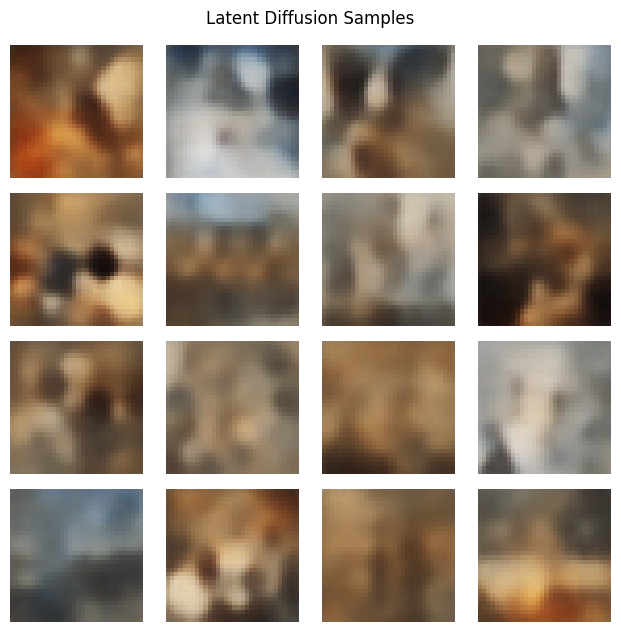

In [31]:
import torchvision.utils as vutils
latent_shape = (16, 4, 4, 4)

latents = latent_diffusion.p_sample_loop(
    model = latent_model,
    shape=latent_shape
)

vae.eval()
with torch.no_grad():
    images = vae.decoder(latents)

show_image_grid(images, title="Latent Diffusion Samples")

In [56]:
# --- COMPARATIVE EVALUATION SETTINGS ---
N_EVAL = 5000  # Number of samples for statistically significant FID/KID
diffusion_results = {}

# Prepare real images from the test set as the ground truth distribution
# Using the test loader is more rigorous for final results [cite: 12]
real_images = collect_real_images_from_loader(test_loader_diffusion, max_images=N_EVAL)
real_uint8 = to_uint8_artbench10(real_images)

# --- EVALUATE PIXEL DIFFUSION ---
print("Sampling from Pixel Diffusion...")
pixel_samples = sample_from_pixel_diffusion(pixel_model, pixel_diffusion, num_samples=N_EVAL)
pixel_uint8 = to_uint8_artbench10(pixel_samples)
fid_pixel, kid_pixel = compute_fid(real_uint8, pixel_uint8)

diffusion_results['Pixel Diffusion'] = {'fid': fid_pixel, 'kid': kid_pixel}

# --- EVALUATE LATENT DIFFUSION ---
print("Sampling from Latent Diffusion...")
# Uses the function we defined earlier which includes the VAE decoder 
latent_samples = sample_from_diffusion(latent_model, vae, latent_diffusion, num_samples=N_EVAL)
latent_uint8 = to_uint8_artbench10(latent_samples)
fid_latent, kid_latent = compute_fid(real_uint8, latent_uint8)

diffusion_results['Latent Diffusion'] = {'fid': fid_latent, 'kid': kid_latent}

# --- DISPLAY RESULTS TABLE ---
print("\n" + "="*50)
print(f"{'Model Type':<20} | {'FID (↓)':<10} | {'KID (↓)':<10}")
print("-" * 50)
for model, res in diffusion_results.items():
    print(f"{model:<20} | {res['fid']:>10.2f} | {res['kid']:>10.4f}")
print("="*50)

Sampling from Pixel Diffusion...
Generating batch: 64/5000
Generating batch: 128/5000
Generating batch: 192/5000
Generating batch: 256/5000
Generating batch: 320/5000
Generating batch: 384/5000
Generating batch: 448/5000
Generating batch: 512/5000
Generating batch: 576/5000
Generating batch: 640/5000
Generating batch: 704/5000
Generating batch: 768/5000
Generating batch: 832/5000
Generating batch: 896/5000
Generating batch: 960/5000
Generating batch: 1024/5000
Generating batch: 1088/5000
Generating batch: 1152/5000
Generating batch: 1216/5000
Generating batch: 1280/5000
Generating batch: 1344/5000
Generating batch: 1408/5000
Generating batch: 1472/5000
Generating batch: 1536/5000
Generating batch: 1600/5000
Generating batch: 1664/5000
Generating batch: 1728/5000
Generating batch: 1792/5000
Generating batch: 1856/5000
Generating batch: 1920/5000
Generating batch: 1984/5000
Generating batch: 2048/5000
Generating batch: 2112/5000
Generating batch: 2176/5000
Generating batch: 2240/5000
Gen

In [32]:
import itertools
# --- GRID SEARCH FOR LATENT DIFFUSION ----
ldm_search_space = {
    'lr': [1e-4, 5e-5],
    'timesteps': [500, 1000],
    'schedule': ['linear', 'cosine'],
    'model_channels': [64, 128]
}

# 1. Generazione delle combinazioni (8 totali: 2*2*2)
keys = ldm_search_space.keys()
values = ldm_search_space.values()
combinations = list(itertools.product(*values))

ldm_configs = []
for combo in combinations:
    config = dict(zip(keys, combo))
    config['name'] = f"LDM_lr{config['lr']}_T{config['timesteps']}_{config['schedule']}_ch{config['model_channels']}"
    ldm_configs.append(config)

print(f"Ready to test {len(ldm_configs)} Latent Diffusion configurations.")
for cfg in ldm_configs:
    print(f"Testing {cfg['name']}")
    # Here you would implement the training and evaluation loop for each configuration
    # This is a placeholder to show where the logic would go
    # train_diffusion(..., lr=cfg['lr'], schedule=..., model_channels=cfg['model_channels'])
    # sample and compute FID/KID




Ready to test 16 Latent Diffusion configurations.
Testing LDM_lr0.0001_T500_linear_ch64
Testing LDM_lr0.0001_T500_linear_ch128
Testing LDM_lr0.0001_T500_cosine_ch64
Testing LDM_lr0.0001_T500_cosine_ch128
Testing LDM_lr0.0001_T1000_linear_ch64
Testing LDM_lr0.0001_T1000_linear_ch128
Testing LDM_lr0.0001_T1000_cosine_ch64
Testing LDM_lr0.0001_T1000_cosine_ch128
Testing LDM_lr5e-05_T500_linear_ch64
Testing LDM_lr5e-05_T500_linear_ch128
Testing LDM_lr5e-05_T500_cosine_ch64
Testing LDM_lr5e-05_T500_cosine_ch128
Testing LDM_lr5e-05_T1000_linear_ch64
Testing LDM_lr5e-05_T1000_linear_ch128
Testing LDM_lr5e-05_T1000_cosine_ch64
Testing LDM_lr5e-05_T1000_cosine_ch128


In [33]:
# 1. Definisci il file specifico
DIFFUSION_RESULTS_FILE = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/Results/diffusion_results.json")
N_EVAL = 2000

# Prepare real images from the test set as the ground truth distribution
# Using the test loader is more rigorous for final results [cite: 12]
real_images = collect_real_images_from_loader(test_loader_diffusion, max_images=N_EVAL)
real_uint8 = to_uint8_artbench10(real_images)

# 1. Caricamento risultati esistenti per evitare doppioni
all_ldm_results = {}
if DIFFUSION_RESULTS_FILE.exists():
    with open(DIFFUSION_RESULTS_FILE, "r") as f:
        all_ldm_results = json.load(f)
    print(f"Loaded {len(all_ldm_results)} existing Diffusion results.")

print("\n=== STARTING LATENT DIFFUSION GRID SEARCH ===")
for idx, cfg in enumerate(ldm_configs):
    
    """# Skip se la configurazione è già stata calcolata
    if cfg['name'] in all_ldm_results:
        print(f"Skipping {cfg['name']} (already evaluated).")
        continue"""

    print(f"\n--- CONFIG {idx+1}/{len(ldm_configs)}: {cfg['name']} ---")
    
    # A. INITIALIZATION
    # Gestore della diffusione con i parametri della Grid Search
    scheduler = GaussianDiffusion(
        num_timesteps=cfg['timesteps'], 
        schedule=cfg['schedule'], 
        device=device
    )
    
    # A. INITIALIZATION (Continua)
    # Inizializziamo il modello per questa specifica configurazione
    # Usiamo LatentDenoiseNetwork poiché la Grid Search è su Latent Diffusion
    model = LatentDenoiseNetwork(
        latent_channels=4, 
        model_channels=cfg['model_channels'],
        num_res_blocks=3
    ).to(device)

    # Ottimizzatore basato sul Learning Rate della configurazione corrente
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])

    # B. TRAINING PHASE
    # Addestriamo per un numero ridotto di epoche (es. 20) per la Grid Search
    # Usiamo la funzione train_diffusion che hai definito sopra
    print(f"Training {cfg['name']} for 20 epochs...")
    history = fit_or_load_model(
        model=model,
        name=cfg['name'],
        train_function=train_diffusion,
        loader=train_loader_diffusion,
        load_if_available=True,
        schedule=scheduler,
        epochs=20,
        lr=cfg['lr'],
        encode_fn=lambda x: (vae.encoder(x)[0], None)
    )

    # C. EVALUATION PHASE
    # Generiamo i campioni per calcolare FID e KID
    # Usiamo la funzione batch-wise che abbiamo discusso per evitare OOM
    print(f"Sampling {N_EVAL} images for metrics...")
    
    # Nota: Assicurati che latent_shape sia coerente con il tuo VAE (es. 4x4x4 o 4x8x8)
    # Se il tuo VAE comprime 32x32 -> 4x4, allora latent_shape = (batch, 4, 4, 4)
    gen_samples = sample_from_diffusion(
        unet=model, 
        vae=vae, 
        scheduler=scheduler, 
        num_samples=N_EVAL, 
        batch_size=64 
    )
    
    # Conversione e calcolo metriche
    gen_uint8 = to_uint8_artbench10(gen_samples)
    fid_val, kid_val = compute_fid(real_uint8, gen_uint8)

    # D. PERSISTENCE
    # Salviamo i risultati nel JSON centralizzato usando la tua funzione update_results_json
    update_results_json(
        file_path=DIFFUSION_RESULTS_FILE, 
        config_name=cfg['name'], 
        fid=fid_val, 
        kid=kid_val
    )
    
    # Salviamo i pesi del modello per questa configurazione
    DIFFUSION_CKPT_DIR = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/")
    save_diffusion_model(
        unet=model, 
        vae=vae, 
        history=history, 
        cfg=cfg, 
        ckpt_dir=DIFFUSION_CKPT_DIR
    )

    # Aggiorniamo il dizionario locale per evitare di ripetere il calcolo in caso di riavvio
    all_ldm_results[cfg['name']] = {'fid': fid_val, 'kid': kid_val}
    print(f"✔️ Completed {cfg['name']} | FID: {fid_val:.2f} | KID: {kid_val:.4f}")

    # E. CLEANUP
    # Liberiamo la memoria GPU per la prossima iterazione
    del model
    del optimizer
    torch.cuda.empty_cache()

print("\n" + "="*60)
print("GRID SEARCH COMPLETED SUCCESSFULLY")
print("="*60)

# --- IDENTIFICAZIONE DEL MIGLIOR MODELLO ---

if all_ldm_results:
    # Troviamo la configurazione con il FID più basso
    best_cfg_name = min(all_ldm_results, key=lambda k: all_ldm_results[k]['fid'])
    best_metrics = all_ldm_results[best_cfg_name]

    print("\n" + "*"*60)
    print("🏆 BEST CONFIGURATION FOUND")
    print("*"*60)
    print(f"Configuration Name: {best_cfg_name}")
    print(f"FID Score:         {best_metrics['fid']:.2f}")
    print(f"KID Score:         {best_metrics['kid']:.4f}")
    print("*"*60)

Loaded 14 existing Diffusion results.

=== STARTING LATENT DIFFUSION GRID SEARCH ===

--- CONFIG 1/16: LDM_lr0.0001_T500_linear_ch64 ---
Training LDM_lr0.0001_T500_linear_ch64 for 20 epochs...
Upload model "LDM_lr0.0001_T500_linear_ch64" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/ldm_lr0_0001_t500_linear_ch64.pth
Sampling 2000 images for metrics...
Generating Latent batch: 64/2000
Generating Latent batch: 128/2000
Generating Latent batch: 192/2000
Generating Latent batch: 256/2000
Generating Latent batch: 320/2000
Generating Latent batch: 384/2000
Generating Latent batch: 448/2000
Generating Latent batch: 512/2000
Generating Latent batch: 576/2000
Generating Latent batch: 640/2000
Generating Latent batch: 704/2000
Generating Latent batch: 768/2000
Generating Latent batch: 832/2000
Generating Latent batch: 896/2000
Generating Latent batch: 960/2000
Generating Latent batch: 1024/2000
Generating Latent batch: 1088/2000
Generating Latent batch: 1152/2000
Generating Late

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation mig

Results for 'LDM_lr0.0001_T500_linear_ch64' saved in: diffusion_results.json
Latent Diffusion model 'LDM_lr0.0001_T500_linear_ch64' and results saved to /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models
✔️ Completed LDM_lr0.0001_T500_linear_ch64 | FID: 214.86 | KID: 0.1874

--- CONFIG 2/16: LDM_lr0.0001_T500_linear_ch128 ---
Training LDM_lr0.0001_T500_linear_ch128 for 20 epochs...
Upload model "LDM_lr0.0001_T500_linear_ch128" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/ldm_lr0_0001_t500_linear_ch128.pth
Sampling 2000 images for metrics...
Generating Latent batch: 64/2000
Generating Latent batch: 128/2000
Generating Latent batch: 192/2000
Generating Latent batch: 256/2000
Generating Latent batch: 320/2000
Generating Latent batch: 384/2000
Generating Latent batch: 448/2000
Generating Latent batch: 512/2000
Generating Latent batch: 576/2000
Generating Latent batch: 640/2000
Generating Latent batch: 704/2000
Generating Latent batch: 768/2000
Generating Latent batc

In [34]:
def load_diffusion_from_drive(model_name, ckpt_dir, device):
    """
    Carica i pesi di una UNet addestrata partendo dal nome del modello e dalla cartella.
    """
    # 1. Costruisci il percorso del file (deve corrispondere a come hai salvato nel loop)
    unet_path = Path(ckpt_dir) / f"{model_name}_unet.pth"
    
    if not unet_path.exists():
        raise FileNotFoundError(f"Non ho trovato i pesi in: {unet_path}")

    # 2. Inizializza l'architettura con gli stessi parametri usati nel training
    model = LatentDenoiseNetwork(
        latent_channels=4, 
        model_channels=128, 
        num_res_blocks=3
    ).to(device)
    
    # 3. Caricamento effettivo dello stato
    state_dict = torch.load(unet_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    
    print(f"✅ Modello '{model_name}' caricato con successo da Drive.")
    return model

In [35]:
# Estrazione dei dati per le 4 categorie

results_dir = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/Results")

best_ae = get_best_metrics_from_json(results_dir / "convAE_results.json")
best_vae = get_best_metrics_from_json(results_dir / "convVAE_results.json")
best_gan = get_best_metrics_from_json(results_dir / "GAN_results.json")
best_ldm = get_best_metrics_from_json(results_dir / "diffusion_results.json")

# Creazione del dizionario finale
final_comparison = {}
if best_ae: final_comparison['Conv-AE'] = best_ae
if best_vae: final_comparison['Conv-VAE'] = best_vae
if best_gan: final_comparison['DCGAN'] = best_gan
if best_ldm: final_comparison['Latent-Diff'] = best_ldm

# Debug: Verifica dei valori caricati
print("--- Dati per il Benchmark Finale ---")
for model, data in final_comparison.items():
    print(f"{model}: {data['name']} | FID: {data['fid']:.2f} | KID: {data['kid']:.4f}")

--- Dati per il Benchmark Finale ---
Conv-AE: ConvAE_z256_lr0.001_f64_e30 | FID: 75.06 | KID: 0.0414
Conv-VAE: ConvVAE_z128_lr0.001_f64_e20_b0.1 | FID: 183.10 | KID: 0.1547
DCGAN: DCGAN_z100_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e30 | FID: 100.23 | KID: 0.0626
Latent-Diff: LDM_lr5e-05_T1000_cosine_ch64 | FID: 163.52 | KID: 0.1305


Best AE: ConvAE_z256_lr0.001_f64_e30 | FID: 75.06
Best VAE: ConvVAE_z128_lr0.001_f64_e20_b0.1 | FID: 183.10
Best GAN: DCGAN_z100_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e30 | FID: 100.23
Best Diffusion: LDM_lr5e-05_T1000_cosine_ch64 | FID: 163.52


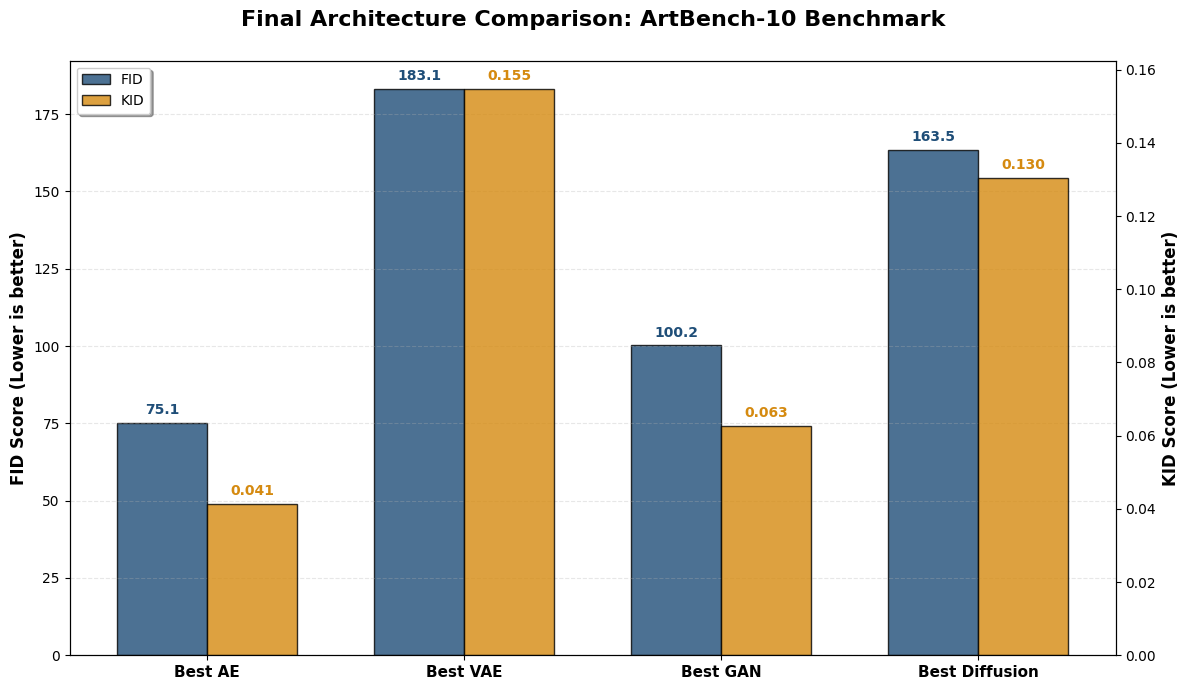

In [36]:
results_dir = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/Results")

# Estraiamo i migliori per ogni categoria
best_ae = get_best_metrics_from_json(results_dir / "convAE_results.json")
best_vae = get_best_metrics_from_json(results_dir / "convVAE_results.json")
best_gan = get_best_metrics_from_json(results_dir / "GAN_results.json")
best_diffusion = get_best_metrics_from_json(results_dir / "diffusion_results.json")

# Creiamo il dizionario per il grafico
final_comparison = {}
if best_ae: final_comparison['Best AE'] = best_ae
if best_vae: final_comparison['Best VAE'] = best_vae
if best_gan: final_comparison['Best GAN'] = best_gan
if best_diffusion: final_comparison['Best Diffusion'] = best_diffusion

# Debug: stampiamo i vincitori
for model, data in final_comparison.items():
    print(f"{model}: {data['name']} | FID: {data['fid']:.2f}")

def plot_final_benchmark(comparison_data):
    if not comparison_data:
        print("Nessun dato da visualizzare.")
        return

    labels = list(comparison_data.keys())
    fids = [comparison_data[m]['fid'] for m in labels]
    kids = [comparison_data[m]['kid'] for m in labels]
    
    x = np.arange(len(labels))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Barre FID (Asse Sinistro) - Colore Blu Navy per un look accademico
    bar1 = ax1.bar(x - width/2, fids, width, label='FID', color='#1f4e78', edgecolor='black', alpha=0.8)
    ax1.set_ylabel('FID Score (Lower is better)', fontweight='bold', fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Barre KID (Asse Destro) - Colore Arancione/Oro
    ax2 = ax1.twinx()
    bar2 = ax2.bar(x + width/2, kids, width, label='KID', color='#d58a10', edgecolor='black', alpha=0.8)
    ax2.set_ylabel('KID Score (Lower is better)', fontweight='bold', fontsize=12)

    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, fontsize=11, fontweight='bold')
    plt.title('Final Architecture Comparison: ArtBench-10 Benchmark', fontsize=16, pad=25, fontweight='bold')
    
    # Legenda unificata (per evitare doppie legende che coprono le barre)
    lines = [bar1, bar2]
    labels_legend = [l.get_label() for l in lines]
    ax1.legend(lines, labels_legend, loc='upper left', frameon=True, shadow=True)
    
    # Aggiunta etichette sopra le barre FID
    for i, f in enumerate(fids):
        ax1.text(i - width/2, f + (max(fids)*0.01), f'{f:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1f4e78')
    
    # Aggiunta etichette sopra le barre KID
    for i, k in enumerate(kids):
        ax2.text(i + width/2, k + (max(kids)*0.01), f'{k:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#d58a10')

    fig.tight_layout()
    
    # Salvataggio per il report
    plt.savefig(results_dir / "final_comparison_benchmark.png", dpi=300)
    plt.show()

# Esegui il plot
plot_final_benchmark(final_comparison)


## FINAL COMPARISON and METRICS

## FID Metrics

In [27]:
import torch_fidelity

def to_uint8_artbench10(x):
    # x è un tensore in [0,1], lo portiamo a [0,255] e lo convertiamo in uint8
    x = x.clamp(0, 1)
    x = (x * 255).to(torch.uint8)
    return x

def collect_real_images_from_loader(loader, max_images=5000):
    xs = []
    count = 0
    for x, _, _ in loader:
        xs.append(x)
        count += x.size(0)
        if count >= max_images:
            break
    x_all = torch.cat(xs, dim=0)[:max_images]
    return x_all

def sample_from_AE(model, loader, images=5000):
    model.eval()
    zs = []
    cont = 0

    with torch.no_grad():

        for x, _, _ in loader:
            x = x.to(device)

            # latent vector
            z = model.encode(x)
            zs.append(z.cpu())
            cont += x.size(0)
            if cont >= images:
                break
    z_all = torch.cat(zs, dim=0)[:images]

    z = z_all[torch.randperm(z_all.size(0))[:images]].to(device)  # shuffle e subset

    with torch.no_grad():
        xhat = model.decode(z).cpu().clamp(0, 1)
    return xhat

def sample_from_VAE(model, images=5000):
    model.eval()
    zs = []
    cont = 0

    with torch.no_grad():

        # random numbers from normal distribution
        z_random = torch.randn(images, model.latent_dim).to(device)

        x_hat = model.decode(z_random).cpu().clamp(0, 1)
    return x_hat

def sample_from_gan(model, num_samples=5000, latent_dim=128):
    model.eval()
    with torch.no_grad():
        # Generate random noise
        noise = torch.randn(num_samples, latent_dim, 1, 1, device=device)

        # Generator
        fake_images = model(noise)

        # Return in [0,1] from [-1,1]
        fake_images = denorm(fake_images).clamp(0,1)

        return fake_images.cpu()

def sample_from_diffusion(unet, vae, scheduler, num_samples=5000, batch_size=64):
    unet.eval()
    vae.eval()
    all_samples = []
    generated_so_far = 0

    # Parametri spaziali del latente (es. 16 canali * 4 * 4 = 256 totali)
    latent_channels = 4 
    h_lat, w_lat = 4, 4

    while generated_so_far < num_samples:
        current_batch_size = min(batch_size, num_samples - generated_so_far)
        
        # FORMA 4D: [Batch, Canali, Altezza, Larghezza]
        shape = (current_batch_size, latent_channels, h_lat, w_lat)
        
        print(f"Generating Latent batch: {generated_so_far + current_batch_size}/{num_samples}")
        
        with torch.no_grad():
            # 1. Denoising nello spazio latente 4D
            latents = scheduler.p_sample_loop(unet, shape)
            
            # 2. Se il tuo VAE decoder si aspetta un vettore piatto, 
            # dovrai fare .view(current_batch_size, -1) qui.
            # Se il decoder è convoluzionale, lo lasci così.
            imgs = vae.decoder(latents) 
            
            imgs = denorm(imgs).cpu().clamp(0, 1)
            all_samples.append(imgs)
            
        generated_so_far += current_batch_size
        torch.cuda.empty_cache()
        
    return torch.cat(all_samples, dim=0)

def sample_from_pixel_diffusion(unet, scheduler, num_samples=5000, image_size=32, batch_size=64):
    """
    Generates images in pixel space using sub-batches to avoid CUDA Out of Memory errors.
    """
    unet.eval()
    all_samples = []
    generated_so_far = 0

    while generated_so_far < num_samples:
        # Calcola quanti campioni generare in questo step
        current_batch_size = min(batch_size, num_samples - generated_so_far)
        shape = (current_batch_size, 3, image_size, image_size)
        
        print(f"Generating batch: {generated_so_far + current_batch_size}/{num_samples}")
        
        with torch.no_grad():
            # Genera il sub-batch usando la tua classe GaussianDiffusion
            batch_images = scheduler.p_sample_loop(unet, shape)
            # Denormalizza e sposta in CPU per liberare memoria GPU immediatamente
            batch_images = denorm(batch_images).cpu().clamp(0, 1)
            all_samples.append(batch_images)
            
        generated_so_far += current_batch_size
        # Pulizia manuale della cache GPU tra un batch e l'altro
        torch.cuda.empty_cache()
        
    # Concatena tutti i sub-batch in un unico tensore finale
    return torch.cat(all_samples, dim=0)



In [28]:
import tempfile
from pathlib import Path
from PIL import Image

# save images to disk for FID calculation
def save_images_for_fid(images, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for i in range(images.size(0)):
        img = images[i].permute(1, 2, 0).cpu().numpy() 
         # CxHxW -> HxWxC
        Image.fromarray(img).save(out_dir/f'{i:05d}.png')

def compute_fid(real_batch_u8, gen_batch_u8):
    with tempfile.TemporaryDirectory() as tmpdir:
        real_dir = Path(tmpdir) / 'real'
        gen_dir = Path(tmpdir) / 'gen'
        save_images_for_fid(real_batch_u8, real_dir)
        save_images_for_fid(gen_batch_u8, gen_dir)
        metrics = torch_fidelity.calculate_metrics(
            input1=str(real_dir), 
            input2=str(gen_dir), 
            cuda=torch.cuda.is_available(), 
            fid=True, 
            kid=True,
            kid_subset_size=100,
            kid_subset=50, 
            verbose=False)
    return float(metrics['frechet_inception_distance']), float(metrics['kernel_inception_distance_mean'])

In [25]:
final_train_loader, final_test_loader = build_artbench_loaders(
    train_hf,
    test_hf,
    batch_size=BATCH_SIZE,
    use_gan_norm=True,
    train_ids=None
)

print(f"Immagini per addestramento: {len(final_train_loader.dataset)}")

# Inserisco il miglior modello
# 1. Recupero solo la "ricetta" (config)
config_data, _ = load_model_from_drive("best_GAN")

print(config_data)

# 2. Creo un modello NUOVO
netG = Generator(latent_dim=config_data['z'], ngf=config_data['filters'][0]).to(device)
netD = Discriminator(ndf=config_data['filters'][1]).to(device)

# 3. RICALCOLO I PESI (Inizializzazione casuale/standard)
init_dcgan_weights(netG)
init_dcgan_weights(netD)

# OPTIMIZER CONFIGURATION
opt_g = torch.optim.Adam(netG.parameters(), lr=config_data['lr'][0], betas=(0.5, 0.999))
opt_d = torch.optim.Adam(netD.parameters(), lr=config_data['lr'][1], betas=(0.5, 0.999))

# Training
history = train_gan(
    generator=netG, 
    discriminator=netD, 
    dataloader=final_train_loader, 
    latent_dim=config_data['z'], 
    num_epochs=config_data['epochs'],
    opt_g=opt_g,
    opt_d=opt_d
)


# Una volta finito, calcolo il FID usando il TEST SET come riferimento

Preprocessing: using GAN/Diffusion normalization ([-1,1])
Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Immagini per addestramento: 50000
{'z': 100, 'lr': [0.0001, 0.0004], 'epochs': 30, 'filters': [64, 64], 'name': 'DCGAN_z100_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e30'}
Epoch 1/30 - Gen Loss: 6.7740, Disc Loss: 0.2872
Epoch 2/30 - Gen Loss: 4.6973, Disc Loss: 0.3205
Epoch 3/30 - Gen Loss: 3.9433, Disc Loss: 0.3619
Epoch 4/30 - Gen Loss: 3.9361, Disc Loss: 0.3615
Epoch 5/30 - Gen Loss: 3.4722, Disc Loss: 0.4936
Epoch 6/30 - Gen Loss: 3.3858, Disc Loss: 0.4699
Epoch 7/30 - Gen Loss: 3.5835, Disc Loss: 0.4365
Epoch 8/30 - Gen Loss: 3.6553, Disc Loss: 0.3912
Epoch 9/30 - Gen Loss: 3.7255, Disc Loss: 0.3964
Epoch 10/30 - Gen Loss: 3.6855, Disc Loss: 0.3508
Epoch 11/30 - Gen Loss: 3.7687, Disc Loss: 0.4005
Epoch 12/30 - Gen Loss: 3.8947, Disc Loss: 0.3411
Epoch 13/30 - Gen Loss: 3.9793, Disc Loss: 0.3392
Epoch 14/30 - Gen Loss: 4.1378, Disc Loss: 0.2575
Epoch 15/30 -

In [29]:
# Try 10 different seeds
N_REPETITIONS = 10
N_FID_SAMPLES = 5000

gan_fid_scores = [] 
gan_kid_scores = []

print(f"Starting evaluation protocol (10 repetitions), {N_FID_SAMPLES} samples for FID/KID calculation each time...")

# Usiamo il test loader finale (standardizzato) per le immagini reali di confronto
# Le immagini reali sono costanti per tutte le ripetizioni
print(f"Preparo {N_FID_SAMPLES} immagini reali dal test set...")
real_images = collect_real_images_from_loader(final_test_loader, max_images=N_FID_SAMPLES)
# Se il loader usa GAN norm [-1, 1], dobbiamo denormalizzare a [0, 1] prima del FID
real_images = denorm(real_images) 
real_uint8 = to_uint8_artbench10(real_images.cpu())

print(f"Inizio valutazione GAN (10 ripetizioni) con {N_FID_SAMPLES} campioni...")

for i in range(N_REPETITIONS):
    # Cambiamo seed per ogni iterazione per variare il rumore generato
    current_seed = SEED + i
    torch.manual_seed(current_seed)
    
    # 1. Generazione campioni sintetici
    # netG si aspetta (B, Z, 1, 1)
    with torch.no_grad():
        gen_images = sample_from_gan(
        model=netG, 
        num_samples=N_FID_SAMPLES, 
        latent_dim=config_data['z']
    )
    
    # 2. Conversione in uint8
    gen_uint8 = to_uint8_artbench10(gen_images)

    # 3. Calcolo metriche
    f_gan, k_gan = compute_fid(real_uint8, gen_uint8)

    gan_fid_scores.append(f_gan)
    gan_kid_scores.append(k_gan)

    # Cleanup
    del gen_images, gen_uint8
    torch.cuda.empty_cache()

    print(f"Ripetizione {i+1}/10 completata | FID: {f_gan:.2f}")

# --- REPORT FINALE ---
print("\n" + "="*40)
print(f"📊 RISULTATI FINALI DCGAN ({N_REPETITIONS} seeds)")
print(f"Dataset: ArtBench-10 | Campioni: {N_FID_SAMPLES}")
print("-" * 40)
print(f"GAN FID: {np.mean(gan_fid_scores):.2f} ± {np.std(gan_fid_scores):.2f}")
print(f"GAN KID: {np.mean(gan_kid_scores):.4f} ± {np.std(gan_kid_scores):.4f}")
print("="*40)

Starting evaluation protocol (10 repetitions), 5000 samples for FID/KID calculation each time...
Preparo 5000 immagini reali dal test set...
Inizio valutazione GAN (10 ripetizioni) con 5000 campioni...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ripetizione 1/10 completata | FID: 63.65
Ripetizione 2/10 completata | FID: 64.73
Ripetizione 3/10 completata | FID: 64.30
Ripetizione 4/10 completata | FID: 63.79
Ripetizione 5/10 completata | FID: 64.45
Ripetizione 6/10 completata | FID: 63.09
Ripetizione 7/10 completata | FID: 65.10
Ripetizione 8/10 completata | FID: 66.08
Ripetizione 9/10 completata | FID: 63.76
Ripetizione 10/10 completata | FID: 64.50

📊 RISULTATI FINALI DCGAN (10 seeds)
Dataset: ArtBench-10 | Campioni: 5000
----------------------------------------
GAN FID: 64.35 ± 0.81
GAN KID: 0.0456 ± 0.0012
